<a id="top"></a>

<h1 style="text-align:center; font-size:2.2em; margin-bottom:0.2em;">Brain Tumor Classification with Transfer Learning</h1>


<div style="padding:10px; border-left:4px solid #4F81BD; background:#f7f9fc; margin:12px 0;">
This notebook studies a <b>multi-class MRI classification</b> problem for distinguishing several brain tumor categories and a normal class.
The main objective is to compare transfer-learning models, justify the modeling choices, and test whether the selected models generalize to a different dataset.
</div>

## Table of contents
1. Dataset selection  
2. Dataset description and balancing  
3. Data preprocessing  
4. Model building and evaluation  
5. Model comparison and model selection  
6. Hyperparameter tuning  
7. External testing on a second dataset  
8. Final remarks and references

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Dataset Selection

For this project, the selected source dataset is the **Brain Tumor Classification Dataset** hosted on Kaggle. It contains **brain MRI images** grouped into multiple diagnostic categories, which makes it suitable for a **multi-class image classification** workflow.

### Classes used in the project
- Meningioma           
- Astrocitoma           
- NORMAL               
- Schwannoma            
- Neurocitoma           
- Carcinoma             
- Papiloma              
- Oligodendroglioma     
- Glioblastoma          
- Ependimoma            
- Tuberculoma           
- Meduloblastoma        
- Germinoma             
- Granuloma             
- Ganglioglioma  

### Why this dataset fits the project
This dataset is appropriate because it allows the notebook to address a realistic medical-imaging classification problem while remaining computationally manageable for transfer learning experiments. It also provides enough variation to compare different pretrained CNN backbones under the same pipeline.

### Importing the required libraries

This section loads the libraries used for:
- data handling and visualization,
- image preprocessing and generators,
- model construction and training,
- evaluation, comparison, and reporting.

Keeping imports near the beginning makes the workflow easier to audit and reproduce.

In [ ]:
!pip install tensorflow
import os
import re
import requests
from PIL import Image
import pandas as pd
import numpy as np

#libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# import Deep learning Libraries
#preprocessing, modeling & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing import image
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras import regularizers
import warnings
warnings.filterwarnings('ignore')

### Downloading the dataset

The next code cell downloads the dataset directly from Kaggle and prepares the working path used in the rest of the notebook.
This makes the notebook self-contained and easier to reproduce on a different machine or cloud environment.

In [ ]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-44c")

print("Path to dataset files:", path)

filepaths=[]
labels=[]


folds = os.listdir(path)
for fold in folds:
    foldpath = os.path.join(path, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        # Select just tumor name
        fold = str(fold).replace('C+', '')
        labels.append(fold[:-3])


# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis= 1)
df

Using Colab cache for faster access to the 'brain-tumor-mri-images-44c' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-images-44c


,filepaths,labels
0,/kaggle/input/brain-tumor-mri-images-44c/Papil...,Papiloma
1,/kaggle/input/brain-tumor-mri-images-44c/Papil...,Papiloma
2,/kaggle/input/brain-tumor-mri-images-44c/Papil...,Papiloma
3,/kaggle/input/brain-tumor-mri-images-44c/Papil...,Papiloma
4,/kaggle/input/brain-tumor-mri-images-44c/Papil...,Papiloma
...,...,...
4474,/kaggle/input/brain-tumor-mri-images-44c/Germi...,Germinoma
4475,/kaggle/input/brain-tumor-mri-images-44c/Germi...,Germinoma
4476,/kaggle/input/brain-tumor-mri-images-44c/Germi...,Germinoma
4477,/kaggle/input/brain-tumor-mri-images-44c/Germi...,Germinoma


## 2. Dataset Description and Balancing

This task is a **multi-class classification** task: each MRI image is assigned one class label corresponding to a tumor type or to the normal class.

### Why balancing matters
In medical image classification, an imbalanced dataset can bias the model toward the majority classes. For that reason, this notebook inspects the label distribution and applies a balancing step so that model evaluation is not dominated by only the most frequent classes.

### Practical relevance
A model of this type could support:
- pre-screening workflows,
- decision support for radiology review,
- educational and research experimentation in medical AI.

### Splitting the data

The code below separates the data into training, validation, and test partitions.

This decision is important because each split has a different role:
- **training set:** used to fit model parameters,
- **validation set:** used to monitor learning and compare configurations,
- **test set:** used only for final evaluation.

Using separate splits reduces the risk of reporting an overly optimistic result.

In [ ]:

# train dataframe
train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123)

# valid and test dataframe# Stratified split to preserve class proportions
train_df, temp_df = train_test_split(
    df,
    train_size=0.80,
    shuffle=True,
    random_state=123,
    stratify=df["labels"]
)

valid_df, test_df = train_test_split(
    temp_df,
    train_size=0.60,   # 60% of 20% = 12%
    shuffle=True,
    random_state=123,
    stratify=temp_df["labels"]
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape :", test_df.shape)

print("\nClass distribution:")
print("Train:\n", train_df["labels"].value_counts())
print("\nValid:\n", valid_df["labels"].value_counts())
print("\nTest:\n", test_df["labels"].value_counts())
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.6, shuffle= True, random_state= 123)

#80% training - 12% valid - 8% testing

Train shape: (3583, 2)
Valid shape: (537, 2)
Test shape : (359, 2)

Class distribution:
Train:
 labels
Meningioma           699
Astrocitoma          464
_NORMAL              417
Schwannoma           372
Neurocitoma          366
Carcinoma            201
Papiloma             190
Oligodendroglioma    179
Glioblastoma         163
Ependimoma           120
Tuberculoma          116
Meduloblastoma       105
Germinoma             80
Granuloma             62
Ganglioglioma         49
Name: count, dtype: int64

Valid:
 labels
Meningioma           105
Astrocitoma           69
_NORMAL               63
Schwannoma            56
Neurocitoma           54
Carcinoma             30
Papiloma              28
Oligodendroglioma     27
Glioblastoma          25
Ependimoma            18
Tuberculoma           17
Meduloblastoma        16
Germinoma             12
Granuloma             10
Ganglioglioma          7
Name: count, dtype: int64

Test:
 labels
Meningioma           70
Astrocitoma          47
_NORMAL         

In [ ]:
import os
import tempfile
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 64
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Generator used only to create synthetic images for minority classes
aug_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generators for model input
train_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

temp_dir = tempfile.mkdtemp()
augmented_dfs = []

# Count classes ONLY in the training set
class_counts_before = train_df['labels'].value_counts()
target_count = 250

# Augment only underrepresented classes in train_df
classes_to_augment = [cls for cls, count in class_counts_before.items() if count < target_count]

print("Classes to augment:", classes_to_augment)

for class_name in classes_to_augment:
    current_class_df = train_df[train_df['labels'] == class_name].copy()
    num_existing = len(current_class_df)
    num_needed = target_count - num_existing

    if num_needed <= 0:
        continue

    class_temp_dir = os.path.join(temp_dir, class_name.replace(" ", "_"))
    os.makedirs(class_temp_dir, exist_ok=True)

    generator = aug_gen.flow_from_dataframe(
        current_class_df,
        x_col='filepaths',
        y_col='labels',
        target_size=img_size,
        class_mode='categorical',
        batch_size=1,
        shuffle=True,
        save_to_dir=class_temp_dir,
        save_prefix='aug',
        save_format='jpg'
    )

    saved_files = set()

    while len(saved_files) < num_needed:
        next(generator)
        current_files = [
            os.path.join(class_temp_dir, f)
            for f in os.listdir(class_temp_dir)
            if f.lower().endswith(".jpg")
        ]
        saved_files.update(current_files)

    saved_files = list(saved_files)[:num_needed]

    augmented_df = pd.DataFrame({
        'filepaths': saved_files,
        'labels': [class_name] * len(saved_files)
    })

    augmented_dfs.append(augmented_df)

# Final training dataframe = original training split + synthetic train-only samples
if augmented_dfs:
    final_train_df = pd.concat([train_df] + augmented_dfs, ignore_index=True)
else:
    final_train_df = train_df.copy()

class_counts_after = final_train_df['labels'].value_counts()

if len(class_counts_after) > 1:
    top_class = class_counts_after.idxmax()
    top_count = class_counts_after.max()
    second_top_count = class_counts_after.sort_values(ascending=False).iloc[1]

    if top_count > second_top_count:
        print(f"Reducing class '{top_class}' from {top_count} to {second_top_count}")
        keep_df = final_train_df[final_train_df['labels'] != top_class]
        top_class_df = final_train_df[final_train_df['labels'] == top_class].sample(
            n=second_top_count,
            random_state=42
        )
        final_train_df = pd.concat([keep_df, top_class_df], ignore_index=True)

print("\nFinal training class counts:")
print(final_train_df['labels'].value_counts())

# Build generators
train_gen = train_datagen.flow_from_dataframe(
    final_train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

valid_gen = test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Classes to augment: ['Carcinoma', 'Papiloma', 'Oligodendroglioma', 'Glioblastoma', 'Ependimoma', 'Tuberculoma', 'Meduloblastoma', 'Germinoma', 'Granuloma', 'Ganglioglioma']
Found 201 validated image filenames belonging to 1 classes.
Found 190 validated image filenames belonging to 1 classes.
Found 179 validated image filenames belonging to 1 classes.
Found 163 validated image filenames belonging to 1 classes.
Found 120 validated image filenames belonging to 1 classes.
Found 116 validated image filenames belonging to 1 classes.
Found 105 validated image filenames belonging to 1 classes.
Found 80 validated image filenames belonging to 1 classes.
Found 62 validated image filenames belonging to 1 classes.
Found 49 validated image filenames belonging to 1 classes.
Reducing class 'Meningioma' from 699 to 464

Final training class counts:
labels
Astrocitoma          464
Meningioma           464
_NORMAL              417
Schwannoma           372
Neurocitoma          366
Papiloma             250

### Visualising the data

Before training a model, it is useful to inspect class examples and class counts. This helps verify that:
- labels look correct,
- classes are represented as expected,
- balancing decisions can be justified visually rather than assumed.

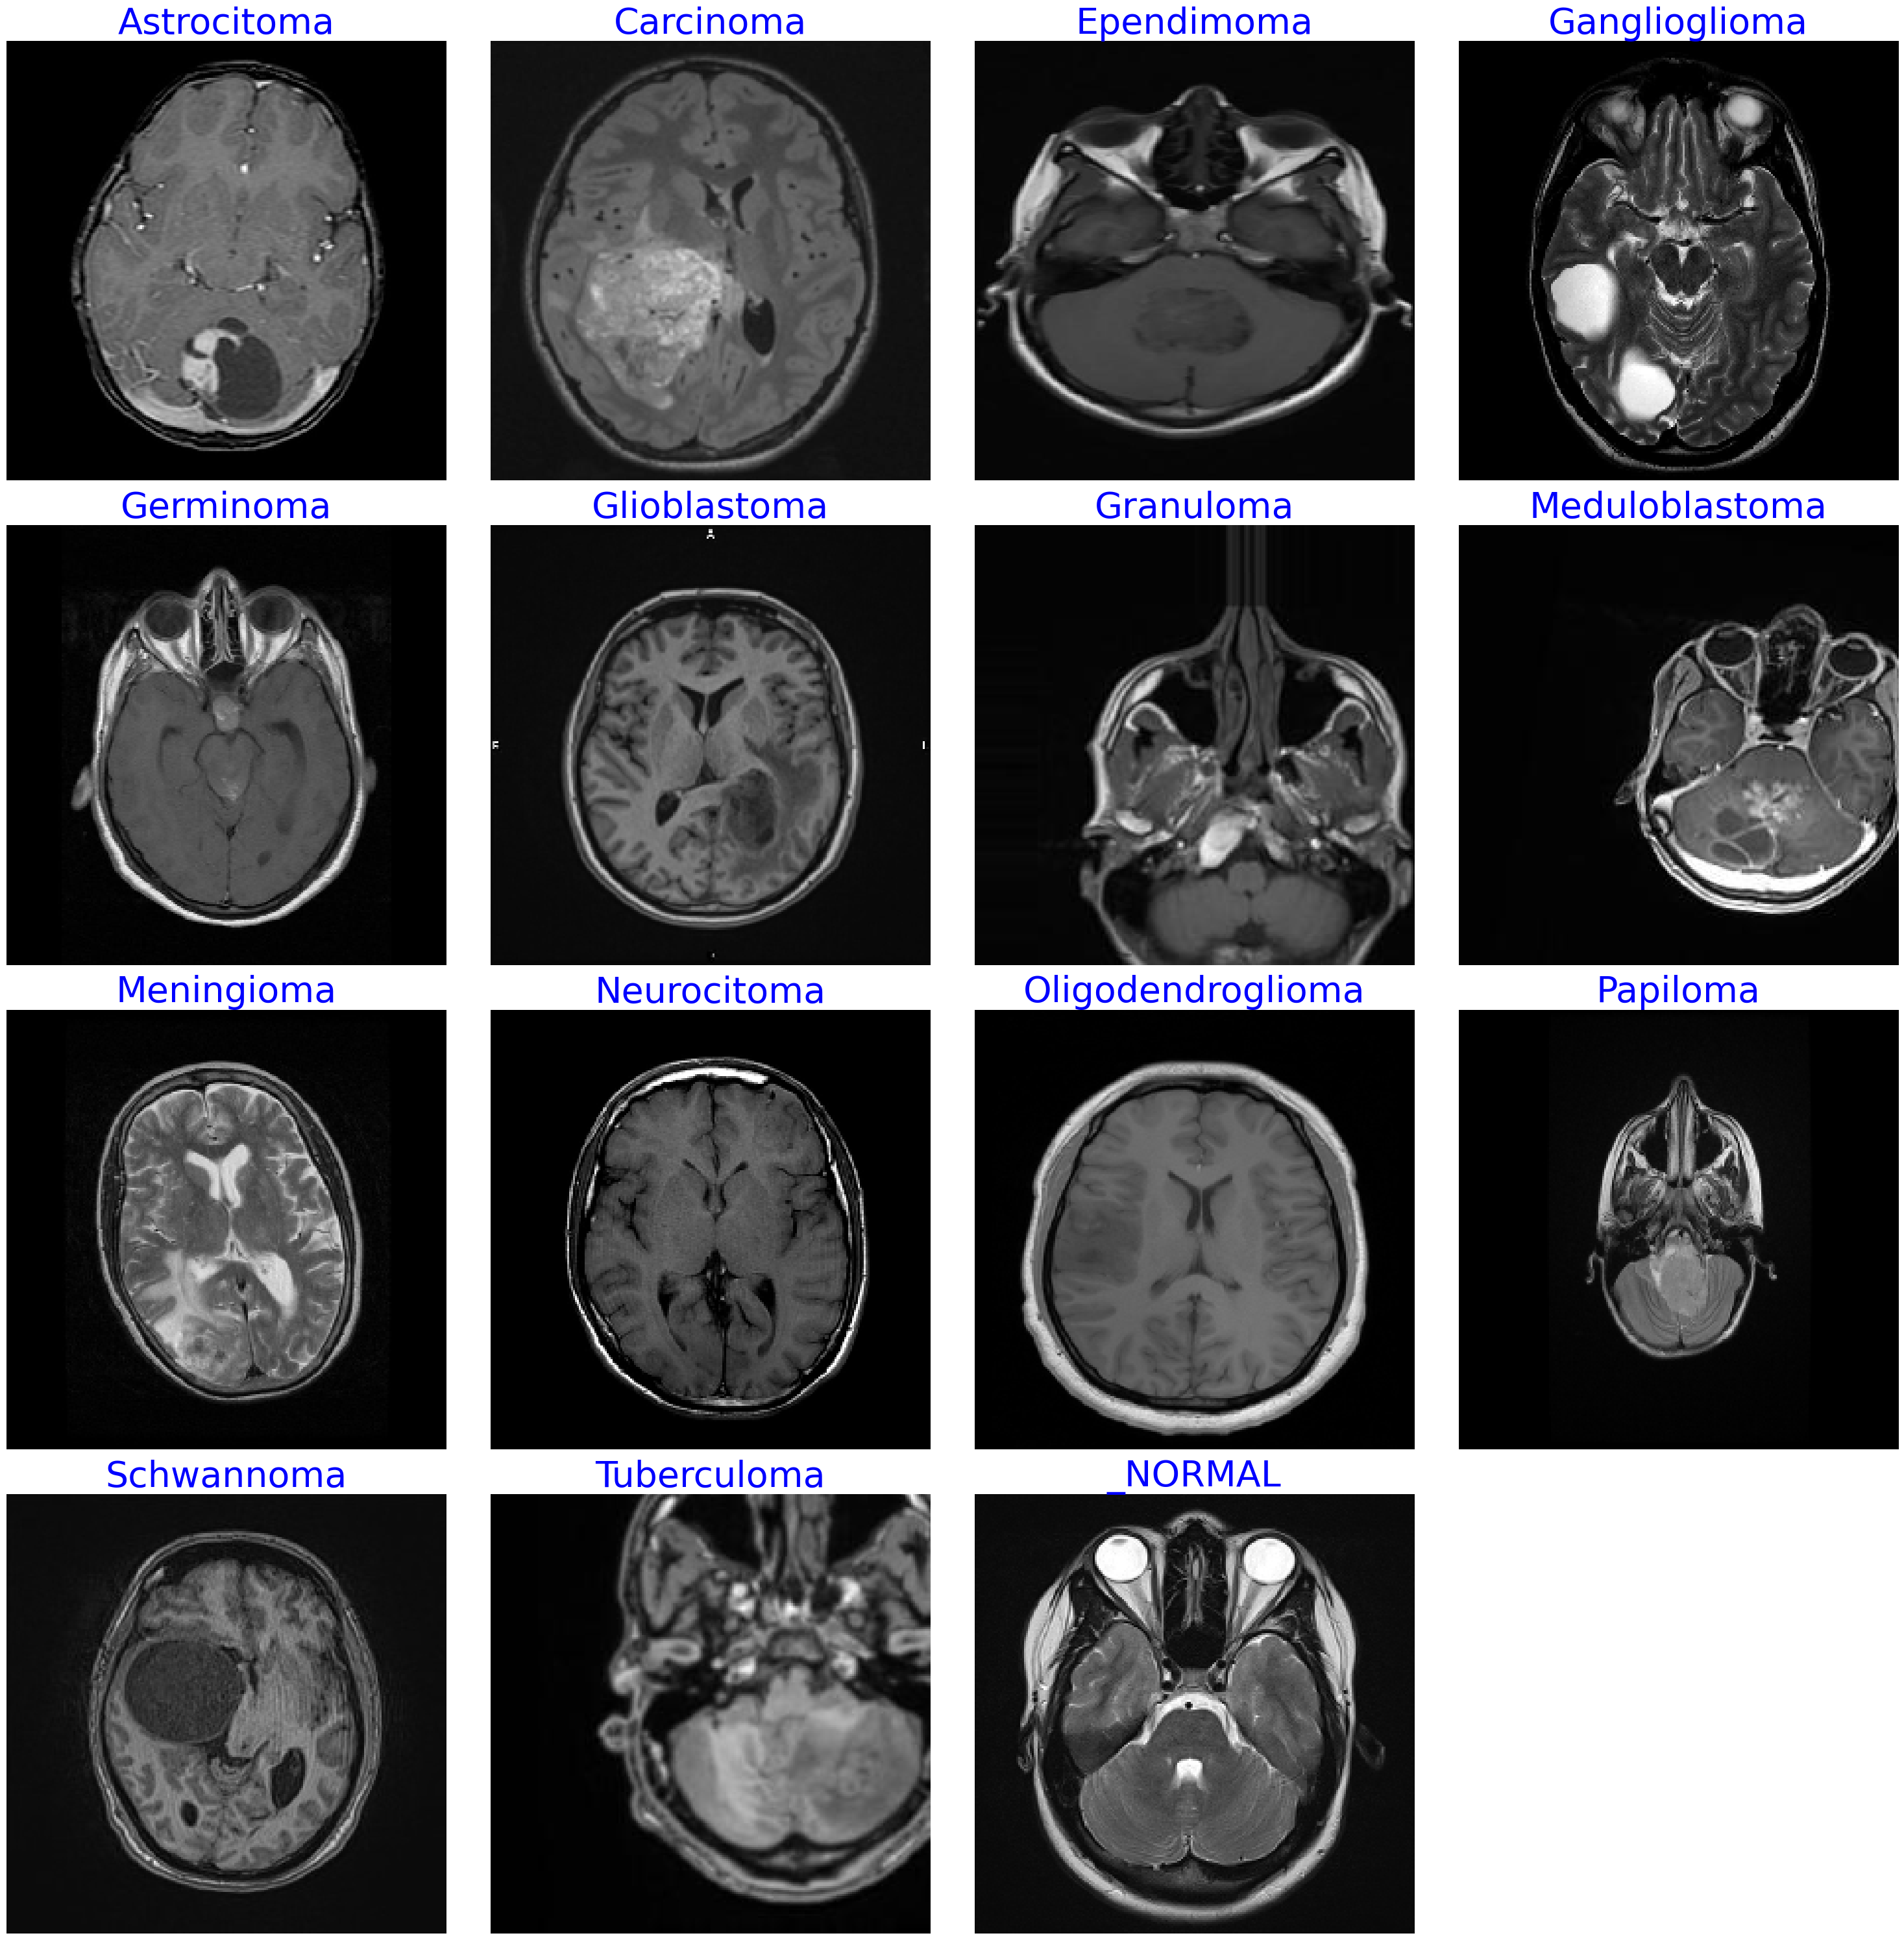

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

g_dict = train_gen.class_indices  # Dictionary mapping class names to indices
classes = list(g_dict.keys())     # List of class names

# Create a dictionary to store one image per class
class_images = {}

# Iterate through the generator until we have one image per class
while len(class_images) < len(classes):
    images, labels = next(train_gen)  # Get a batch of images and labels
    for i in range(images.shape[0]):
        index = np.argmax(labels[i])  # Get the class index
        class_name = classes[index]   # Get the class name
        if class_name not in class_images:
            class_images[class_name] = images[i] / 255  # Store the image

# Plot the images
plt.figure(figsize=(30, 30))
for i, class_name in enumerate(classes):
    plt.subplot(4, 4, i + 1)  # Adjust subplot layout
    plt.imshow(class_images[class_name])
    plt.title(class_name, color='blue', fontsize=40)
    plt.axis('off')
plt.tight_layout()
plt.show()

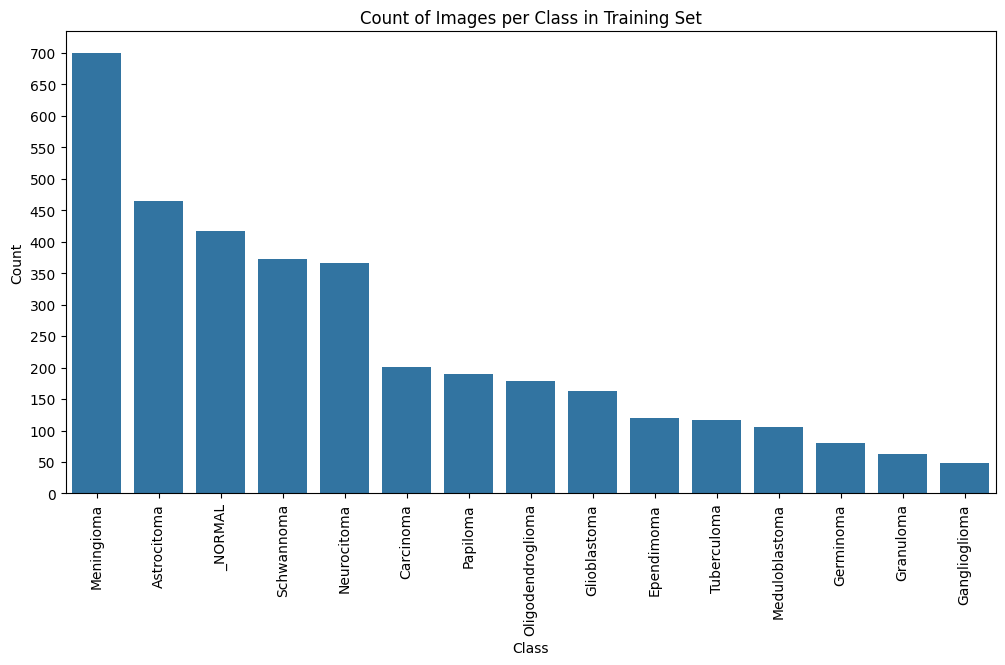

In [ ]:
# Plot class counts using TRAINING DATA ONLY
class_counts_before = train_df['labels'].value_counts()

plt.figure(figsize=(12, 6))
sns.countplot(x='labels', data=train_df, order=class_counts_before.index)
plt.title('Count of Images per Class in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.yticks(range(0, int(class_counts_before.max()) + 50, 50))
plt.show()

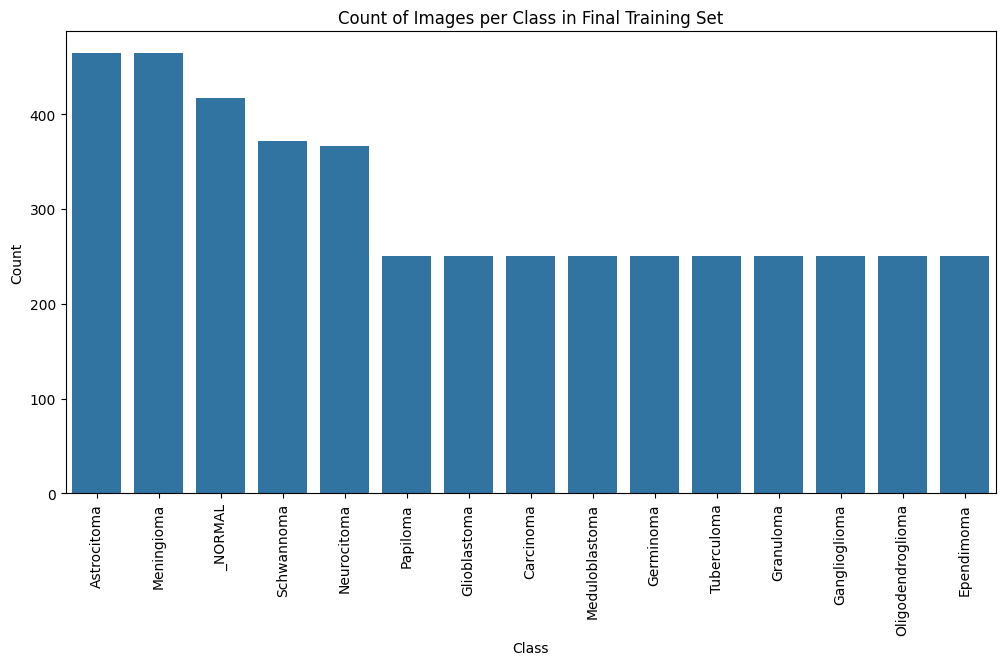

In [ ]:
# Plot class counts AFTER balancing the training set
class_counts_after = final_train_df['labels'].value_counts()

plt.figure(figsize=(12, 6))
sns.countplot(x='labels', data=final_train_df, order=class_counts_after.index)
plt.title('Count of Images per Class in Final Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

## 3. Data Preprocessing

**Data preprocessing** is the set of steps applied before training so that the input data is consistent and usable by the models.

In this notebook, preprocessing is used to:
- convert images into a common input format,
- prepare data generators for training, validation, and testing,
- keep the pipeline consistent across all compared architectures.

This is important because model differences should come mainly from the architectures and training decisions, not from inconsistent input handling.

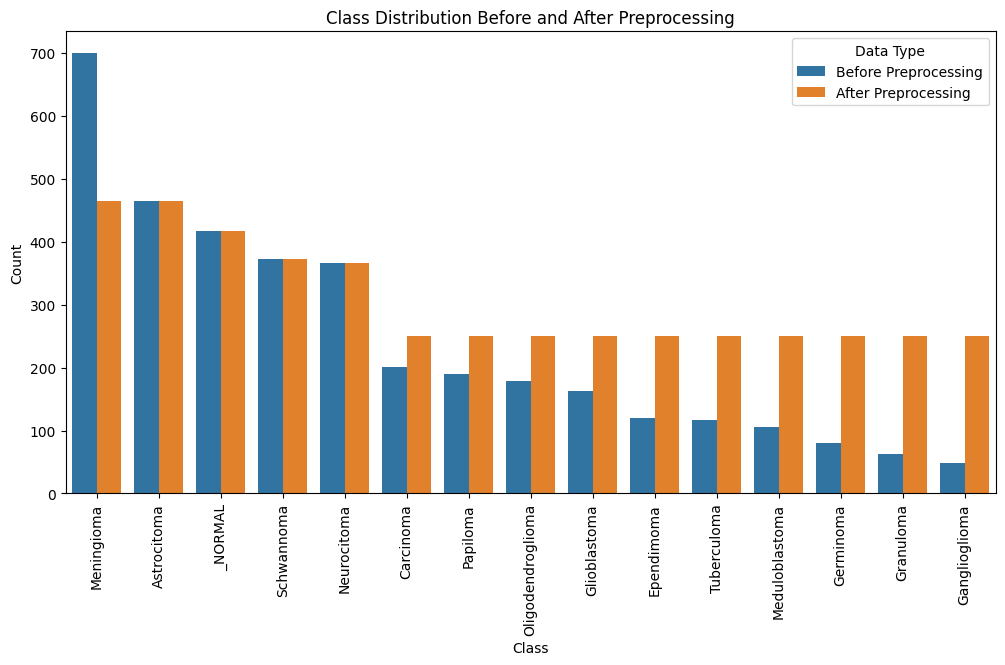

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd



# Create a DataFrame for plotting
before_df = pd.DataFrame({'Class': class_counts_before.index, 'Count': class_counts_before.values, 'Type': 'Before Preprocessing'})
after_df = pd.DataFrame({'Class': class_counts_after.index, 'Count': class_counts_after.values, 'Type': 'After Preprocessing'})
plot_df = pd.concat([before_df, after_df])

# Create the grouped bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', hue='Type', data=plot_df)
plt.title('Class Distribution Before and After Preprocessing')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Data Type')
plt.show()

## 4. Model Building and Evaluation

This section implements and evaluates several transfer-learning models under the same pipeline.

### Definition: Transfer learning
In deep learning, **transfer learning** means starting from a model that has already learned general visual features on a large dataset and adapting it to a new but related task.

> “Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem.”  
> — TensorFlow, *Transfer learning & fine-tuning*

### Why transfer learning is used here
MRI datasets are usually much smaller than large-scale computer-vision datasets. Starting from pretrained weights is therefore a practical decision because it can improve convergence, reduce training time, and provide a stronger baseline than training from scratch.

### Short research notes supporting the modeling choices

- **Transfer learning rationale:** pretrained models are especially useful when the target dataset is limited in size.  
- **EfficientNet rationale:** the family is designed around compound scaling, which makes it a good candidate for comparing smaller and larger backbones.  
- **DenseNet rationale:** dense connectivity promotes feature reuse and gives a structurally different baseline for comparison.

These points explain why the notebook compares EfficientNetB0, EfficientNetB5, and DenseNet121 instead of relying on only one pretrained architecture.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model

def train_model(model, train_gen, valid_gen, epochs=10, verbose=1):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

    history = model.fit(
        x=train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        verbose=verbose,
        callbacks=[early_stop, reduce_lr],
        shuffle=True,
    )

    return history


def plot_history(history):
    tr_acc = history.history['accuracy']
    tr_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']

    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]

    epochs = [i + 1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {index_loss + 1}'
    acc_label = f'best epoch= {index_acc + 1}'

    plt.figure(figsize=(20, 8))
    plt.style.use('fivethirtyeight')

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, tr_loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'g', label='Validation Loss')
    plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, tr_acc, 'r', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation Accuracy')
    plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(model, generator, title="Confusion Matrix"):
    """
    Plots a confusion matrix for a given model and data generator.

    Parameters:
    - model: Trained Keras model
    - generator: Keras generator (usually test_gen)
    - title: Title for the plot
    """
    # Get true labels and predicted labels
    y_true = generator.classes
    y_pred_probs = model.predict(generator, steps=np.ceil(generator.samples / generator.batch_size).astype(int))
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    class_labels = list(generator.class_indices.keys())

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def evaluate_model_performance(model, test_gen):
    # Predict labels
    y_true = test_gen.classes
    y_pred_probs = model.predict(test_gen, steps=test_gen.samples // test_gen.batch_size + 1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Class labels
    class_labels = list(test_gen.class_indices.keys())


    # Classification Report
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Precision, Recall, F1 Score (macro-averaged)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall: {recall:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")

    # Binarize true labels for multi-class ROC and PR curves
    y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))

    # Precision-Recall Curves per class
    precision_dict, recall_dict, pr_auc = {}, {}, {}
    for i in range(len(class_labels)):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
        pr_auc[i] = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])

    # Plot Precision-Recall curves
    plt.figure(figsize=(12, 8))
    for i in range(len(class_labels)):
        plt.plot(recall_dict[i], precision_dict[i], label=f'{class_labels[i]} (AP = {pr_auc[i]:.2f})')
    plt.title('Precision-Recall Curve per Class')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.show()



### Model 1 — EfficientNetB0 baseline

This first model uses **EfficientNetB0** as the pretrained backbone with a custom classification head.

### Research motivation
> “carefully balancing network depth, width, and resolution can lead to better performance.”  
> — Tan & Le, *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks* (2019)

### Why this model is included
EfficientNetB0 is a strong baseline because it is relatively compact while still benefiting from the EfficientNet scaling strategy. In this project, it provides a reference point for comparing a standard head, a simplified head, and a larger EfficientNet variant.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.regularizers import l2

class_count = len(train_gen.class_indices)

# Load the EfficientNetB5 base model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'
)

# Build the full model
efficientNet_model_b0 = Sequential([
    base_model,
    Flatten(),
     Dropout(0.5),
    Dense(256, activation='relu',kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(class_count, activation='softmax')  # Final layer with softmax for multi-class
])

# Compile the model
efficientNet_model_b0.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show the model summary
efficientNet_model_b0.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,362 (16.71 MB)

 Trainable params: 4,339,339 (16.55 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
efficientnet_history = train_model(efficientNet_model_b0, train_gen, valid_gen, epochs=15, verbose=1)


Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.1327 - loss: 7.9926 - val_accuracy: 0.2346 - val_loss: 6.6376 - learning_rate: 0.0010
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 272ms/step - accuracy: 0.2230 - loss: 6.4824 - val_accuracy: 0.3445 - val_loss: 6.1351 - learning_rate: 0.0010
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step - accuracy: 0.3168 - loss: 6.0212 - val_accuracy: 0.4693 - val_loss: 5.6210 - learning_rate: 0.0010
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 310ms/step - accuracy: 0.4054 - loss: 5.6115 - val_accuracy: 0.5587 - val_loss: 5.2907 - learning_rate: 0.0010
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 290ms/step - accuracy: 0.4824 - loss: 5.1923 - val_accuracy: 0.6425 - val_loss: 4.8306 - learning_rate: 0.0010
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 283ms/step - accuracy: 0.5691 - loss: 4.7798 - val_accuracy: 0.7337 - val_loss: 4.3811 - learning_rate: 0.0010
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 290ms/step - accuracy: 0.6182 - loss: 4.44

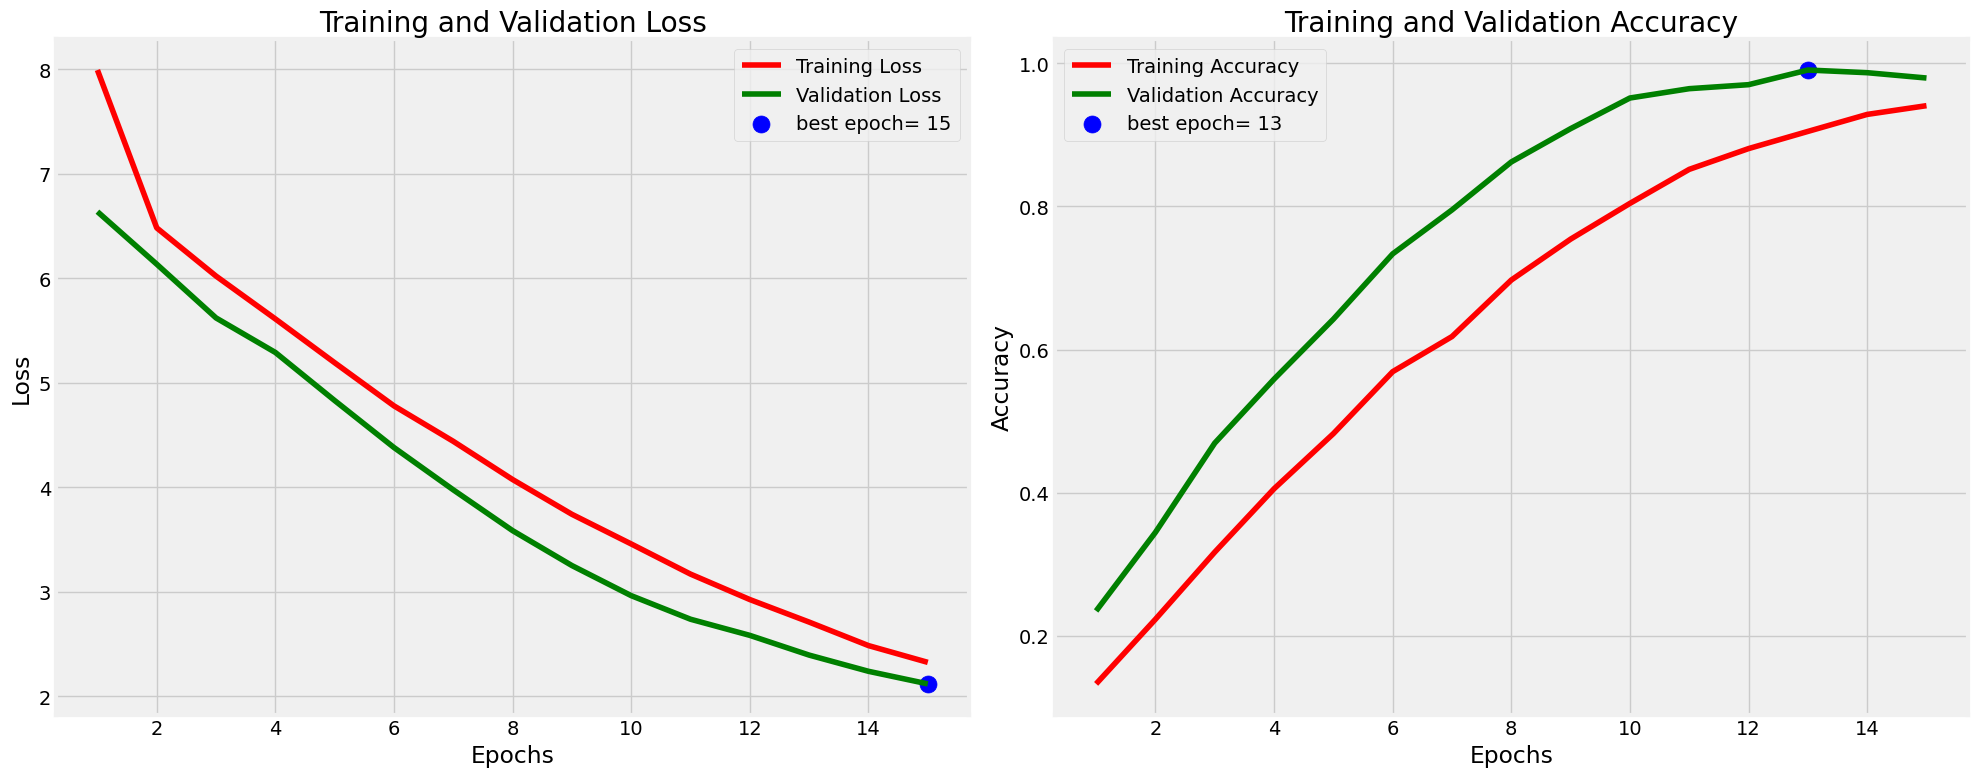

In [ ]:
plot_history(efficientnet_history)

In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = efficientNet_model_b0.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = efficientNet_model_b0.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = efficientNet_model_b0.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9954 - loss: 2.0821  
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9795 - loss: 2.1200    
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9721 - loss: 2.1484    
Train Loss:  2.082138776779175
Train Accuracy:  0.9954178333282471
--------------------
Validation Loss:  2.1199989318847656
Validation Accuracy:  0.9795158505439758
--------------------
Test Loss:  2.148364305496216
Test Accuracy:  0.9721448421478271


6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
Classification Report:

                   precision    recall  f1-score   support

      Astrocitoma       0.98      0.98      0.98        43
        Carcinoma       1.00      1.00      1.00        15
       Ependimoma       0.87      1.00      0.93        13
    Ganglioglioma       1.00      0.75      0.86         4
        Germinoma       0.89      1.00      0.94         8
     Glioblastoma       1.00      1.00      1.00        12
        Granuloma       1.00      0.86      0.92         7
   Meduloblastoma       1.00      1.00      1.00        13
       Meningioma       1.00      0.93      0.96        73
      Neurocitoma       0.96      0.98      0.97        54
Oligodendroglioma       1.00      0.94      0.97        18
         Papiloma       1.00      1.00      1.00        12
       Schwannoma       0.98      1.00      0.99        40
      Tuberculoma       0.88      1.00      0.93         7
          _NORMAL       0.95      1.00      0.98     

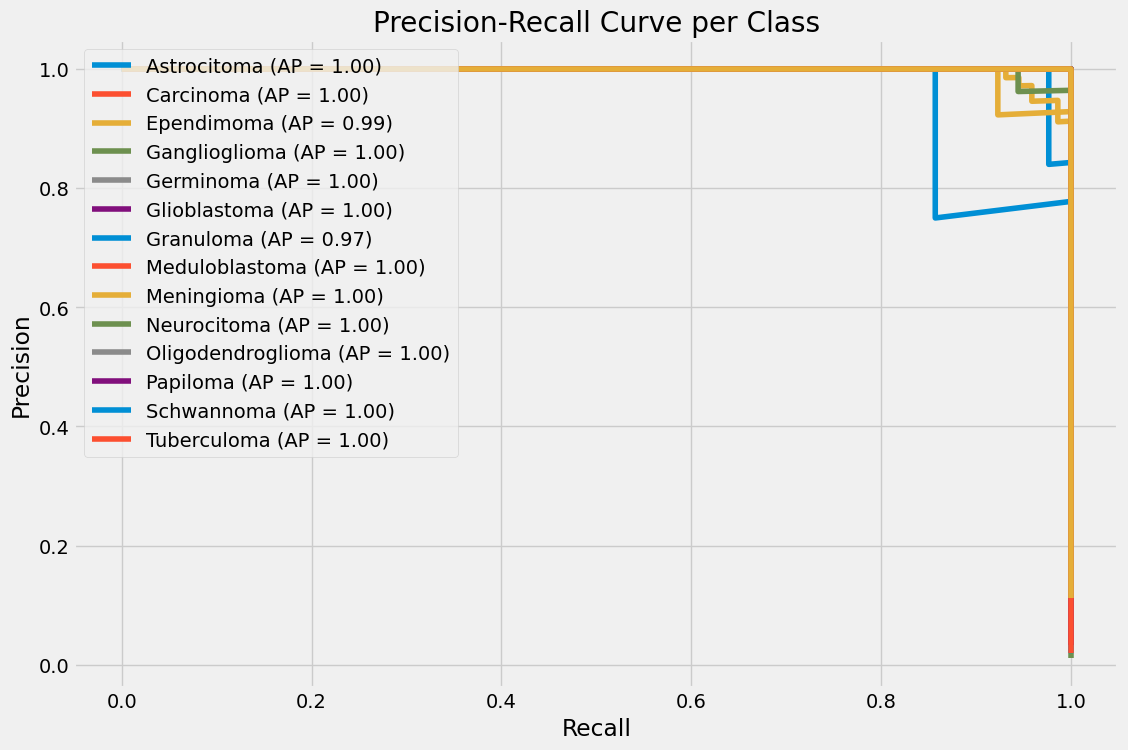

In [ ]:
evaluate_model_performance(efficientNet_model_b0, test_gen)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step


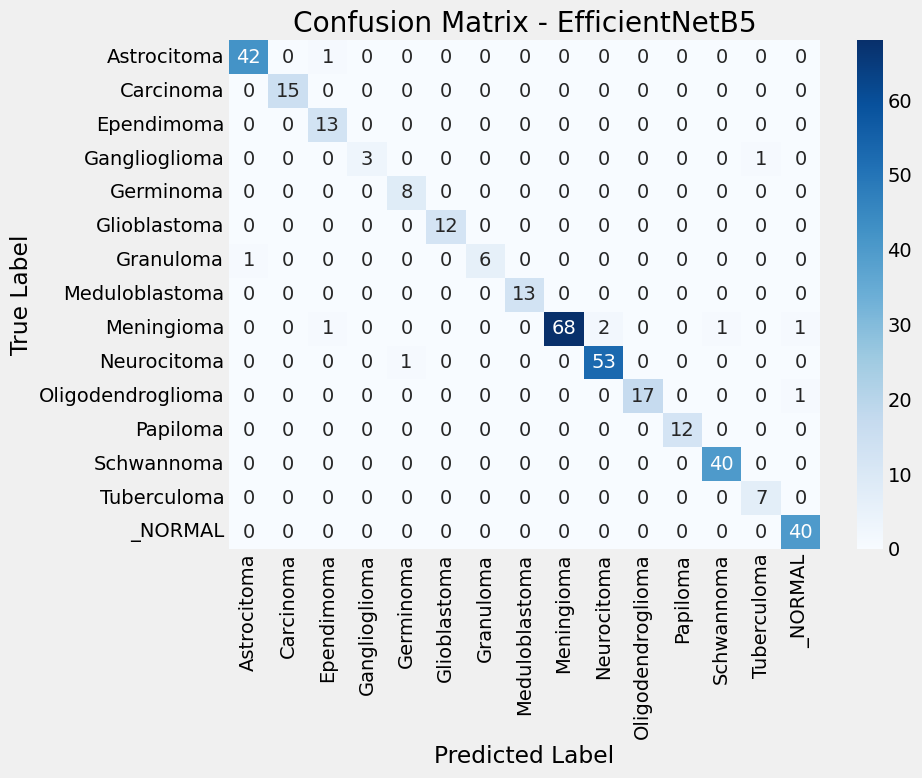

In [ ]:
# Plot confusion matrix for EfficientNetB5
plot_confusion_matrix(efficientNet_model_b0, test_gen, title="Confusion Matrix - EfficientNetB5")



### Model 1B — EfficientNetB0 with a simplified head

This variation keeps the EfficientNetB0 backbone but simplifies the classification head.

### Decision behind this version
A simpler head can reduce the number of trainable parameters in the task-specific layers. The goal is to test whether a lighter top architecture can preserve performance while improving efficiency or reducing overfitting.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

# Number of classes
class_count = len(train_gen.class_indices)

# Load pretrained EfficientNetB0 base model
base_model_Try = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='avg'
)

# Freeze the base model so only the top classifier is trained first
base_model_Try.trainable = False

# Build the model
efficientNet_model_b0R = Sequential([
    base_model_Try,
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(class_count, activation='softmax')
])

# Compile the model
efficientNet_model_b0R.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
efficientNet_model_b0R.summary()

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',          # watch validation loss
    patience=5,                  # stop after 5 epochs without improvement
    restore_best_weights=True,   # go back to the best model
    verbose=1
)

# Train the model
efficientnet_b0R_history = efficientNet_model_b0R.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,474 (16.08 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 59s 548ms/step - accuracy: 0.2322 - loss: 2.3413 - val_accuracy: 0.5102 - val_loss: 1.7833
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.3866 - loss: 1.9013 - val_accuracy: 0.6201 - val_loss: 1.4520
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 225ms/step - accuracy: 0.4691 - loss: 1.6419 - val_accuracy: 0.6592 - val_loss: 1.2656
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.5315 - loss: 1.4739 - val_accuracy: 0.6890 - val_loss: 1.1027
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 234ms/step - accuracy: 0.5782 - loss: 1.3519 - val_accuracy: 0.7412 - val_loss: 0.9837
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 237ms/step - accuracy: 0.6083 - loss: 1.2498 - val_accuracy: 0.7561 - val_loss: 0.9194
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step - accuracy: 0.6341 - loss: 1.1701 - val_accuracy: 0.7728 - val_loss: 0.8556
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 237ms/step - accuracy: 0.6443 - loss: 1.1195 - val_accu

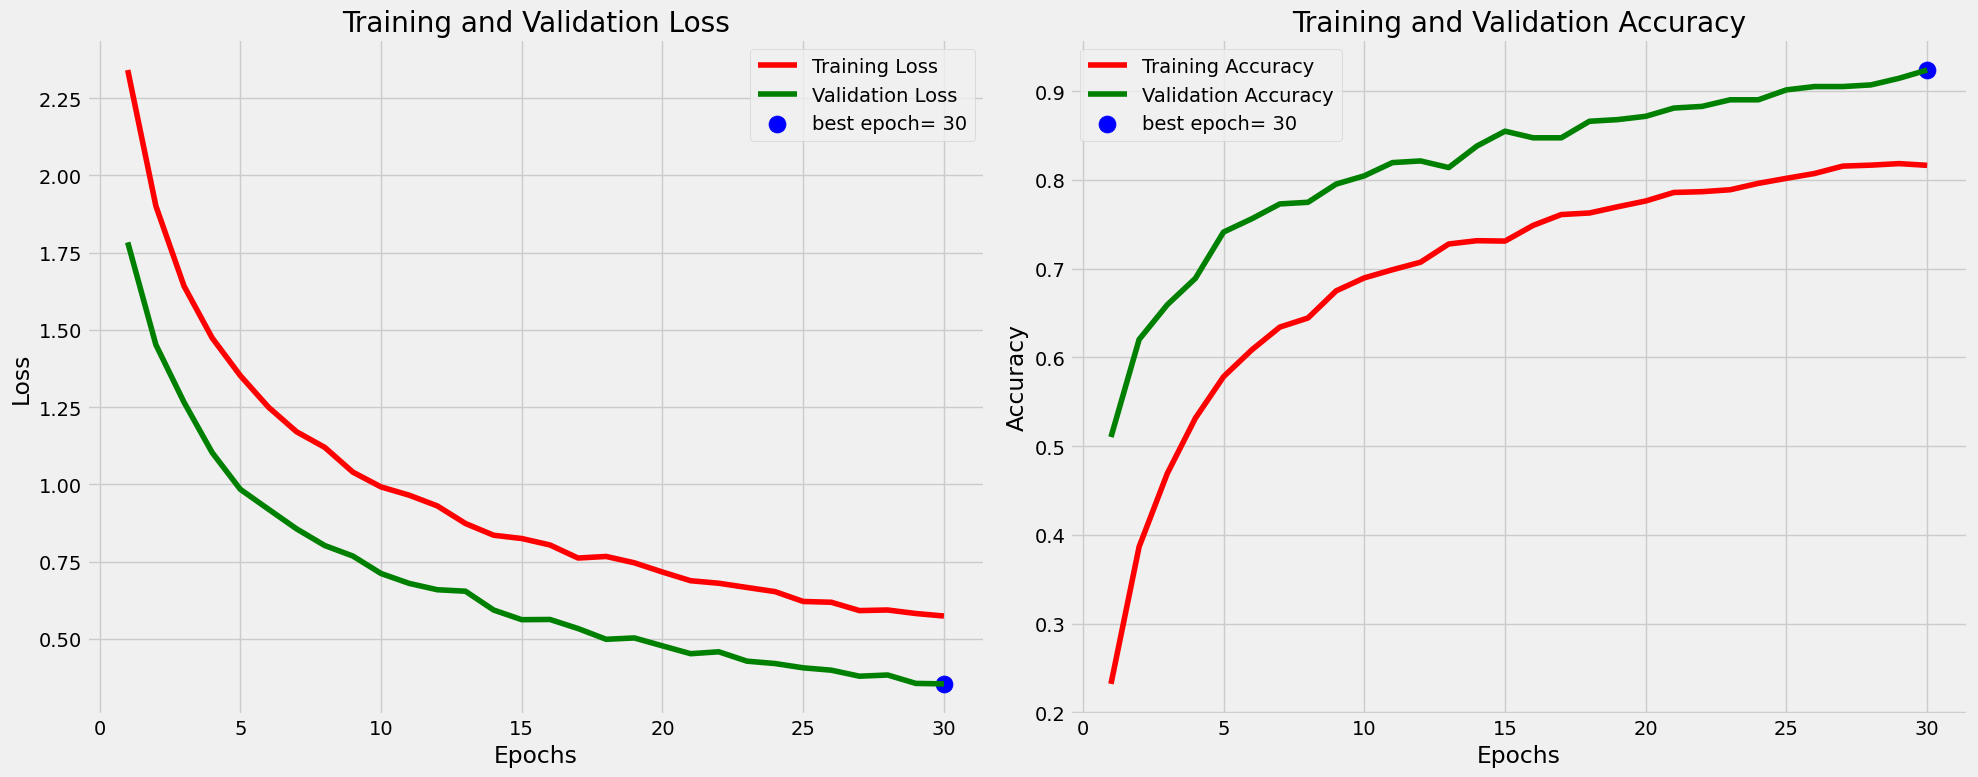

In [ ]:
plot_history(efficientnet_b0R_history)

In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = efficientNet_model_b0R.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = efficientNet_model_b0R.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = efficientNet_model_b0R.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.9385 - loss: 0.2798  
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9236 - loss: 0.3537    
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9164 - loss: 0.3672    
Train Loss:  0.27980270981788635
Train Accuracy:  0.9384682774543762
--------------------
Validation Loss:  0.35373762249946594
Validation Accuracy:  0.9236499071121216
--------------------
Test Loss:  0.36715298891067505
Test Accuracy:  0.9164345264434814


6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step


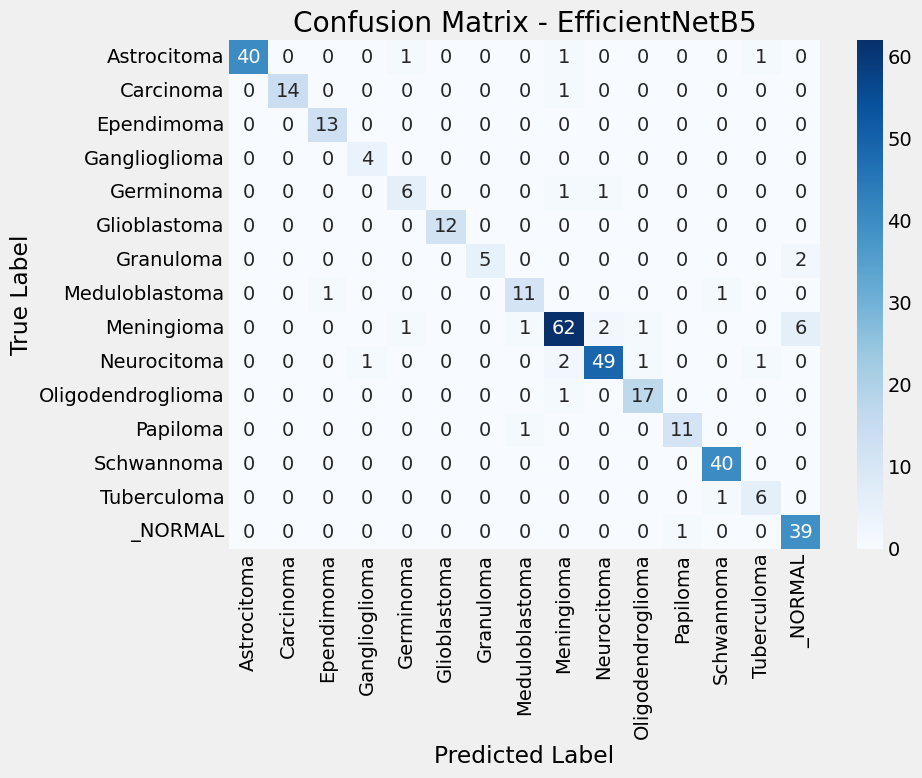

In [ ]:
# Plot confusion matrix for EfficientNetB5
plot_confusion_matrix(efficientNet_model_b0R, test_gen, title="Confusion Matrix - EfficientNetB5")



### Model 2 — EfficientNetB5

This model scales up the EfficientNet family by replacing the B0 backbone with **EfficientNetB5**.

### Why compare B5 against B0
The purpose of this comparison is to check whether a larger pretrained backbone produces a measurable accuracy gain that justifies its added complexity, training cost, and inference burden.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.regularizers import l2

class_count = len(train_gen.class_indices)

# Load the EfficientNetB5 base model
base_model_b5 = EfficientNetB5(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'
)

# Build the full model
efficientNet_model_b5 = Sequential([
    base_model_b5,
    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(class_count, activation='softmax')
])

# Compile the model
efficientNet_model_b5.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show the model summary
efficientNet_model_b5.summary()

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb5 (Functional)     │ (None, 2048)           │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,041,926 (110.79 MB)

 Trainable params: 28,869,183 (110.13 MB)

 Non-trainable params: 172,743 (674.78 KB)

In [ ]:
efficientnet_history_b5 = train_model(efficientNet_model_b5, train_gen, valid_gen, epochs=10, verbose=1)


Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 409s 3s/step - accuracy: 0.1776 - loss: 7.6256 - val_accuracy: 0.3222 - val_loss: 6.4949 - learning_rate: 0.0010
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3834 - loss: 6.1145 - val_accuracy: 0.4655 - val_loss: 5.7525 - learning_rate: 0.0010
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5531 - loss: 5.3414 - val_accuracy: 0.6015 - val_loss: 5.0880 - learning_rate: 0.0010
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7074 - loss: 4.6623 - val_accuracy: 0.6425 - val_loss: 4.7616 - learning_rate: 0.0010
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8174 - loss: 4.0999 - val_accuracy: 0.7914 - val_loss: 4.1516 - learning_rate: 0.0010
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8959 - loss: 3.6440 - val_accuracy: 0.9032 - val_loss: 3.5522 - learning_rate: 0.0010
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9337 - loss: 3.3191 - val_accuracy:

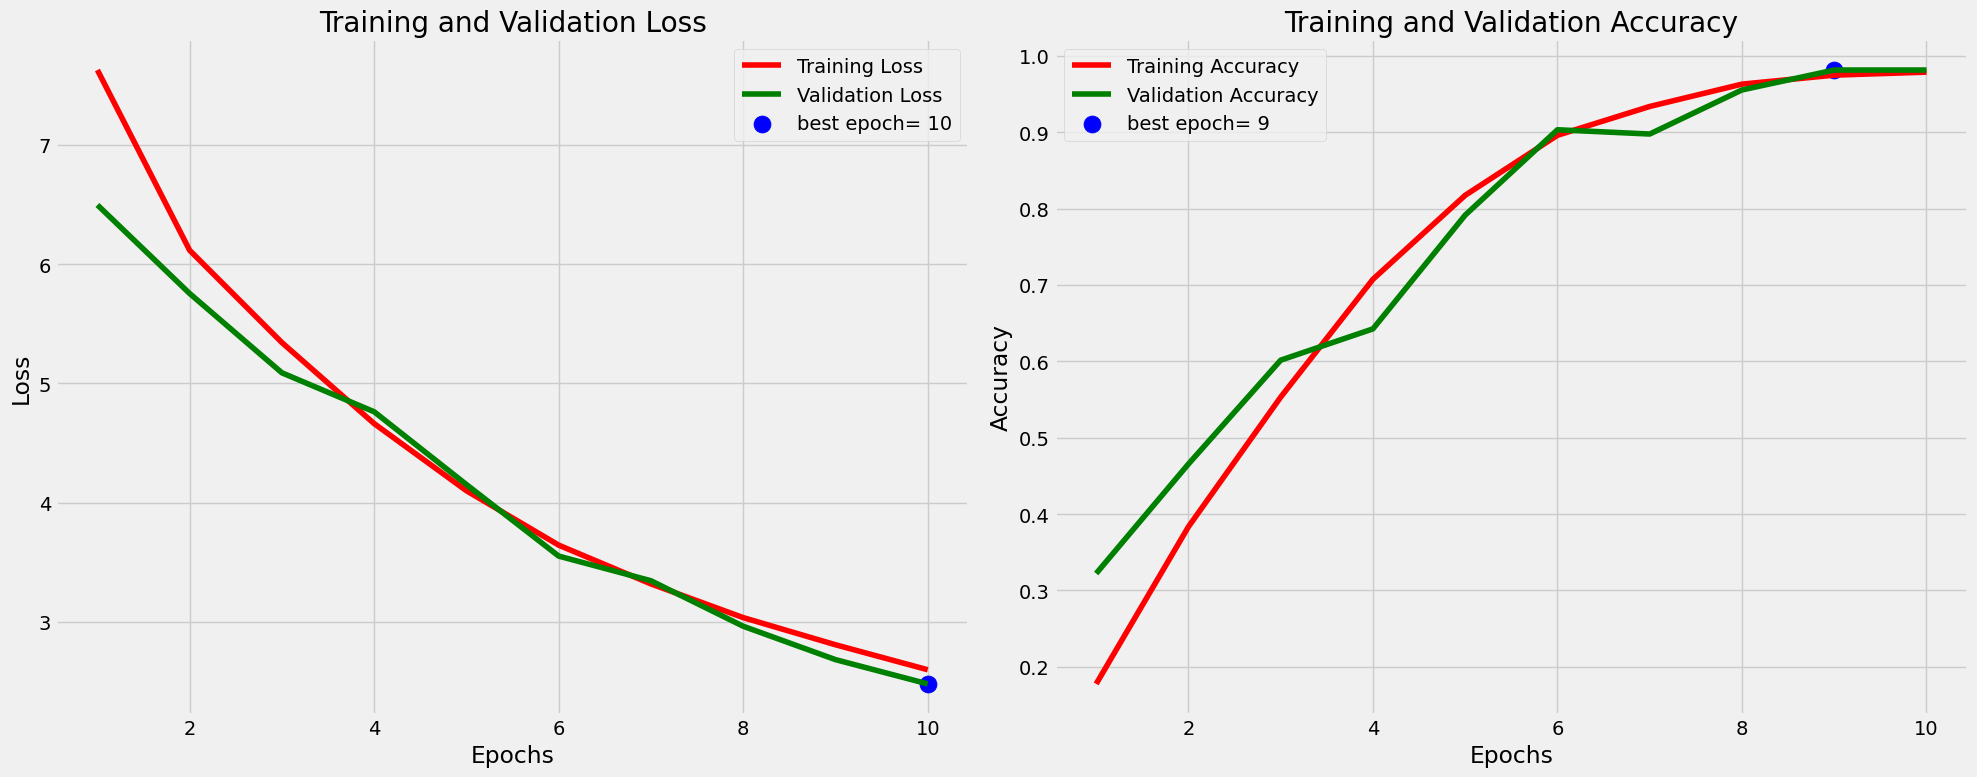

In [ ]:
plot_history(efficientnet_history_b5)

In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = efficientNet_model_b5.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = efficientNet_model_b5.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = efficientNet_model_b5.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

 71/359 ━━━━━━━━━━━━━━━━━━━━ 1:17 271ms/step - accuracy: 0.9984 - loss: 2.4368

6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step


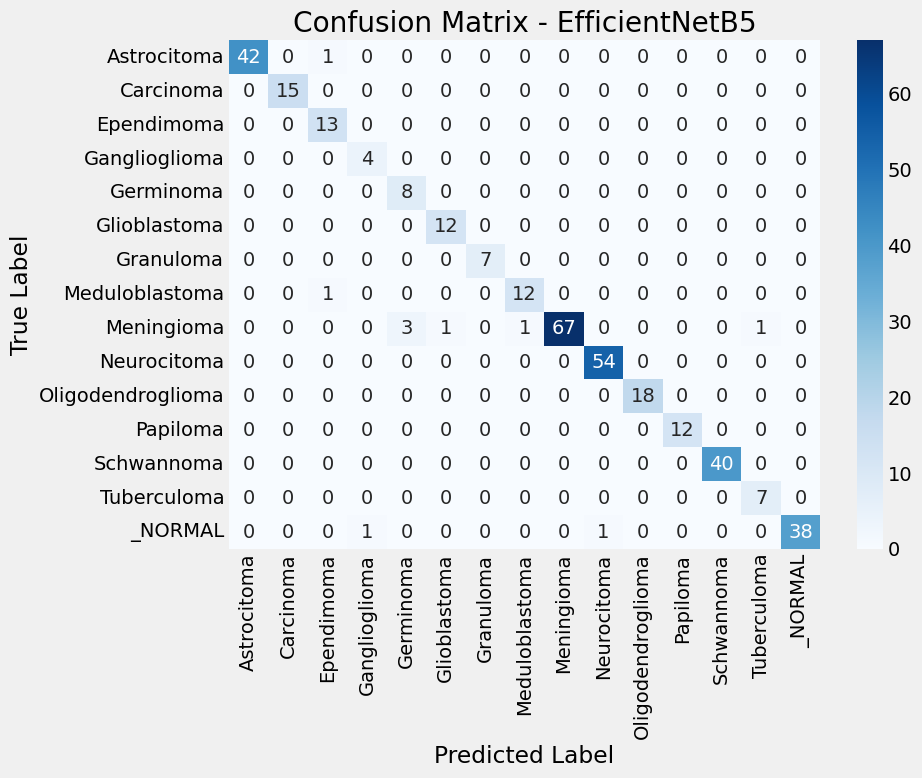

In [ ]:
# Plot confusion matrix for EfficientNetB5
plot_confusion_matrix(efficientNet_model_b5, test_gen, title="Confusion Matrix - EfficientNetB5")


### Model 3 — DenseNet121

This model introduces **DenseNet121** as an alternative transfer-learning backbone.

### Research motivation
> DenseNets “encourage feature reuse, and substantially reduce the number of parameters.”  
> — Huang et al., *Densely Connected Convolutional Networks* (2017)

### Why DenseNet121 is included
DenseNet121 is useful in this comparison because its dense connectivity differs from EfficientNet’s scaling philosophy. Including it gives the project a broader architectural comparison instead of evaluating only one model family.

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.regularizers import l2

# Load the DenseNet121 base model
base_model_d121 = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'  # Global max pooling
)

class_count = len(train_gen.class_indices)

# Build the full model
densenet121_model = Sequential([
    base_model_d121,
    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(class_count, activation='softmax')  # Output layer
])

# Compile the model
densenet121_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
densenet121_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,303,759 (27.86 MB)

 Trainable params: 7,220,111 (27.54 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
DenseNet_history = train_model(densenet121_model, train_gen, valid_gen, epochs=20, verbose=1)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 669ms/step - accuracy: 0.6483 - loss: 2.9434 - val_accuracy: 0.8194 - val_loss: 2.4697 - learning_rate: 0.0010
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 618ms/step - accuracy: 0.6998 - loss: 2.7081 - val_accuracy: 0.8510 - val_loss: 2.3442 - learning_rate: 0.0010
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 653ms/step - accuracy: 0.7652 - loss: 2.4707 - val_accuracy: 0.8994 - val_loss: 2.0678 - learning_rate: 0.0010
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 630ms/step - accuracy: 0.8099 - loss: 2.2602 - val_accuracy: 0.8864 - val_loss: 2.0370 - learning_rate: 0.0010
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 639ms/step - accuracy: 0.8436 - loss: 2.1032 - val_accuracy: 0.8603 - val_loss: 2.0546 - learning_rate: 0.0010
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 634ms/step - accuracy: 0.8721 - loss: 1.9683 - val_accuracy: 0.6294 - val_loss: 3.2243 - learning_rate: 0.0010
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 643ms/step - accuracy: 0.9247 - loss: 1.

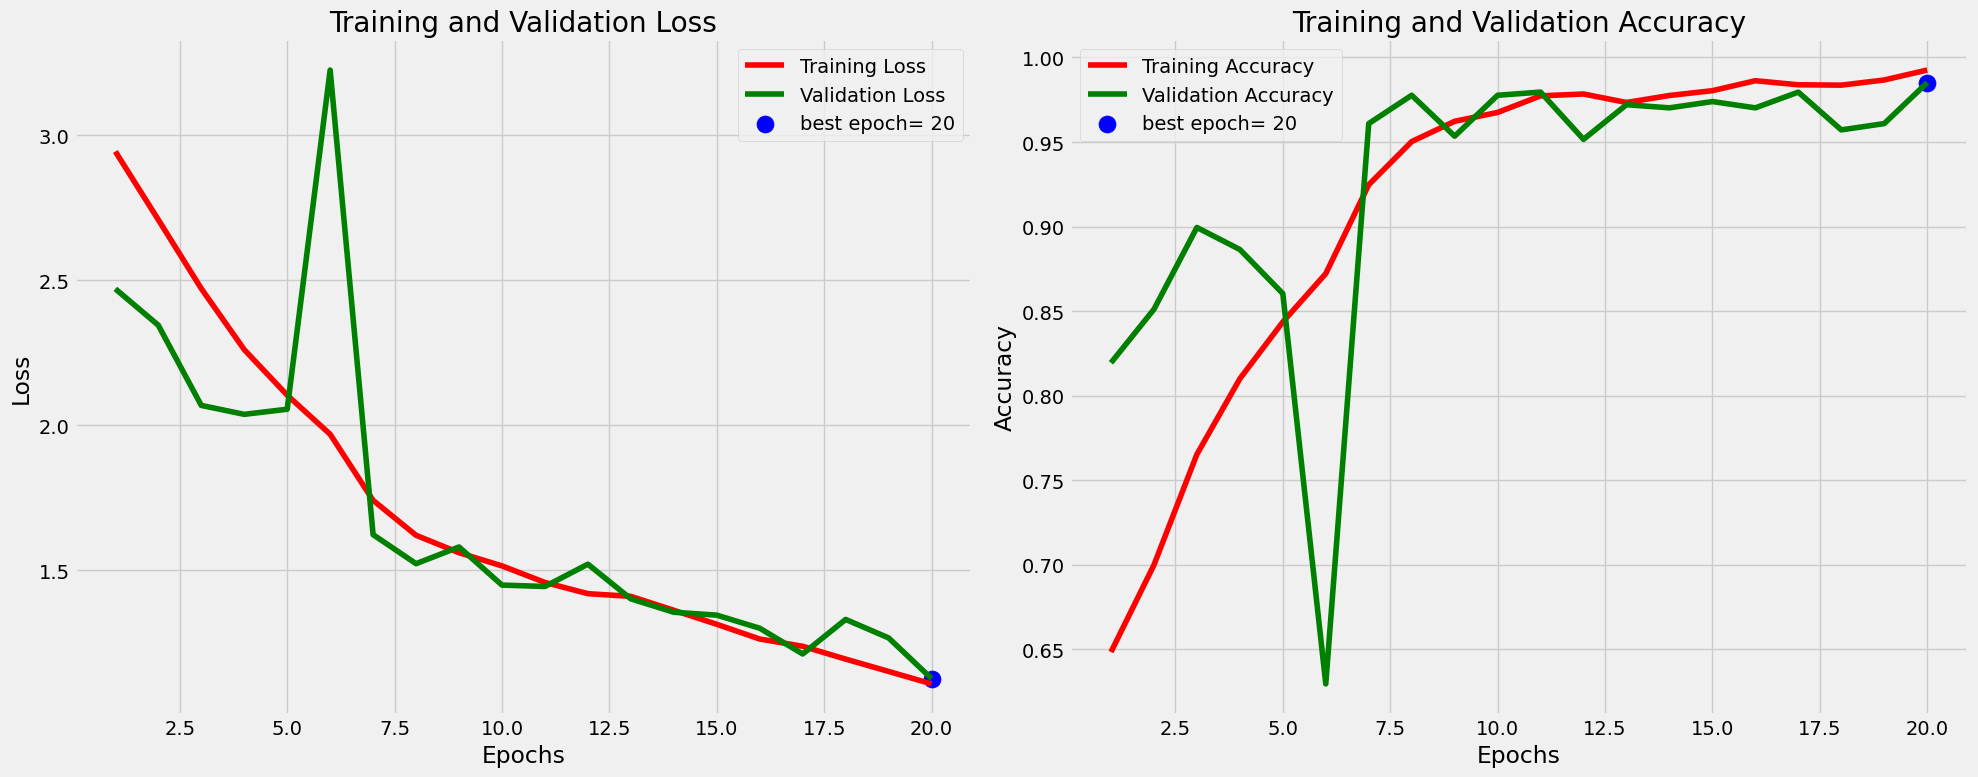

In [ ]:
plot_history(DenseNet_history)

6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step
Classification Report:

                   precision    recall  f1-score   support

      Astrocitoma       1.00      1.00      1.00        43
        Carcinoma       1.00      1.00      1.00        15
       Ependimoma       1.00      1.00      1.00        13
    Ganglioglioma       1.00      1.00      1.00         4
        Germinoma       1.00      1.00      1.00         8
     Glioblastoma       1.00      1.00      1.00        12
        Granuloma       1.00      1.00      1.00         7
   Meduloblastoma       0.93      1.00      0.96        13
       Meningioma       1.00      0.97      0.99        73
      Neurocitoma       1.00      1.00      1.00        54
Oligodendroglioma       0.95      1.00      0.97        18
         Papiloma       1.00      1.00      1.00        12
       Schwannoma       1.00      1.00      1.00        40
      Tuberculoma       1.00      1.00      1.00         7
          _NORMAL       1.00      1.00      1.00     

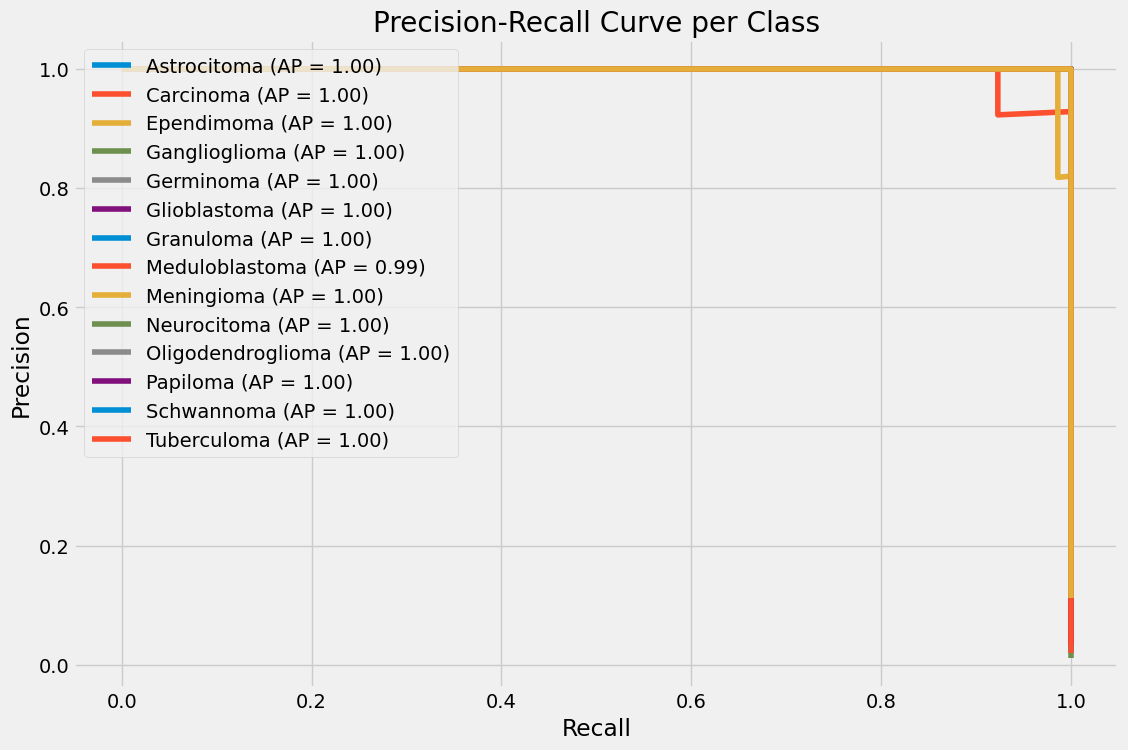

In [ ]:
evaluate_model_performance(densenet121_model, test_gen)


In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = densenet121_model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = densenet121_model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = densenet121_model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.9983 - loss: 1.0710  
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9851 - loss: 1.1259    
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9944 - loss: 1.0975    
Train Loss:  1.0709608793258667
Train Accuracy:  0.9982544183731079
--------------------
Validation Loss:  1.125910758972168
Validation Accuracy:  0.9851024150848389
--------------------
Test Loss:  1.097450852394104
Test Accuracy:  0.9944289922714233


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 228ms/step


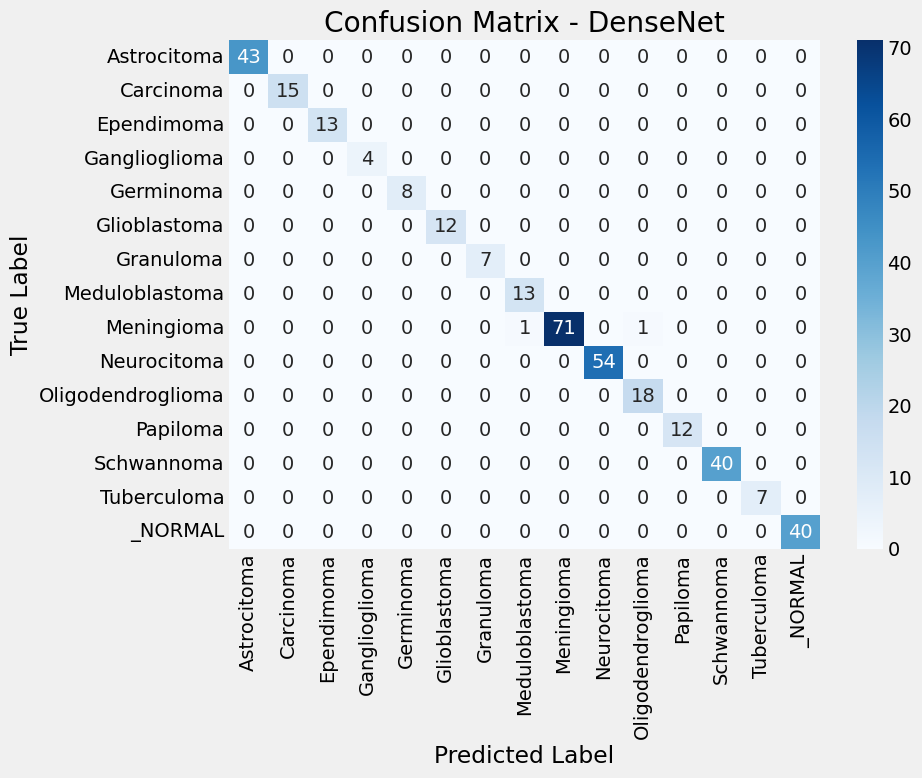

In [ ]:
# Plot confusion matrix for ResNet50
plot_confusion_matrix(densenet121_model, test_gen, title="Confusion Matrix - DenseNet")

## saving

In [ ]:
import os

save_dir = '/content/drive/MyDrive/brain_tumor_project/models'
os.makedirs(save_dir, exist_ok=True)

# Save the 4 trained models
efficientNet_model_b0.save(f'{save_dir}/efficientNet_model_b0.keras')
efficientNet_model_b0R.save(f'{save_dir}/efficientNet_model_b0R.keras')
efficientNet_model_b5.save(f'{save_dir}/efficientNet_model_b5.keras')
densenet121_model.save(f'{save_dir}/densenet121_model.keras')

print("All 4 models saved successfully to Google Drive.")

All 4 models saved successfully to Google Drive.


## 5. Model Comparison and Best Model Selection

At this stage, the notebook compares the trained models using the same evaluation pipeline.

### What this section is trying to decide
The goal is not only to find the model with the highest score, but also to identify the most reasonable candidate for the next step of the project. A good selection should consider:
- validation behavior,
- test accuracy,
- training stability,
- architectural complexity.

This makes the model-selection decision more defensible than choosing a model by a single metric alone.

### Interpretation note

The comparison tables and plots should be read as part of a decision process:
1. identify the strongest baseline,
2. check whether the accuracy gain is meaningful,
3. decide whether the extra complexity is justified,
4. choose one model for tuning.

This makes the workflow resemble a small experimental study rather than a sequence of isolated training runs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_best_history_metrics(history):
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    final_train_acc = history.history['accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    return best_val_acc, best_val_loss, final_train_acc, final_train_loss, best_epoch

# Evaluate all models on the test set
results = []

models_to_compare = [
    ("EfficientNetB0_Original", efficientNet_model_b0, efficientnet_history),
    ("EfficientNetB0_Simplified", efficientNet_model_b0R, efficientnet_b0R_history),
    ("EfficientNetB5", efficientNet_model_b5, efficientnet_history_b5),
    ("DenseNet121", densenet121_model, DenseNet_history),
]

for model_name, model_obj, history_obj in models_to_compare:
    # Evaluate on test set
    test_loss, test_acc = model_obj.evaluate(test_gen, verbose=0)

    # Best validation metrics from history
    best_val_acc, best_val_loss, final_train_acc, final_train_loss, best_epoch = get_best_history_metrics(history_obj)

    # Store total params
    total_params = model_obj.count_params()

    results.append({
        "Model": model_name,
        "Total_Params": total_params,
        "Final_Train_Accuracy": final_train_acc,
        "Final_Train_Loss": final_train_loss,
        "Best_Val_Accuracy": best_val_acc,
        "Best_Val_Loss": best_val_loss,
        "Best_Epoch": best_epoch,
        "Test_Accuracy": test_acc,
        "Test_Loss": test_loss
    })

comparison_df = pd.DataFrame(results)

# Sort by test accuracy first, then validation accuracy
comparison_df = comparison_df.sort_values(
    by=["Test_Accuracy", "Best_Val_Accuracy"],
    ascending=False
).reset_index(drop=True)

print("Model comparison table:")
display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print(f"\nBest model based on test accuracy: {best_model_name}")

Model comparison table:


,Model,Total_Params,Final_Train_Accuracy,Final_Train_Loss,Best_Val_Accuracy,Best_Val_Loss,Best_Epoch,Test_Accuracy,Test_Loss
0,DenseNet121,7303759,0.992581,1.107504,0.985102,1.125911,20,0.994429,1.097451
1,EfficientNetB0_Original,4381362,0.940868,2.326029,0.990689,2.119999,13,0.972145,2.148364
2,EfficientNetB5,29041926,0.978617,2.599743,0.981378,2.481277,9,0.972145,2.532112
3,EfficientNetB0_Simplified,4215474,0.816278,0.573495,0.923650,0.353738,30,0.916435,0.367153



Best model based on test accuracy: DenseNet121


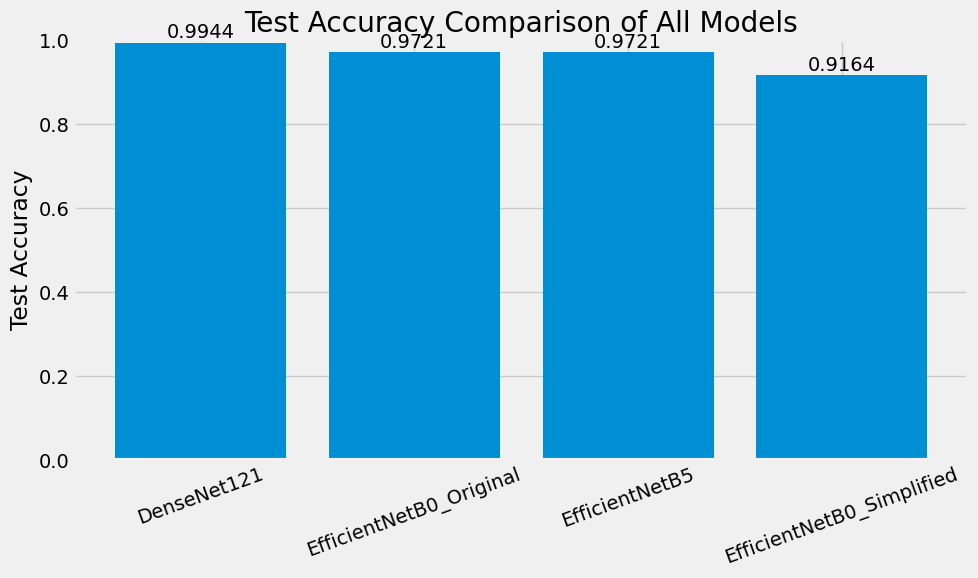

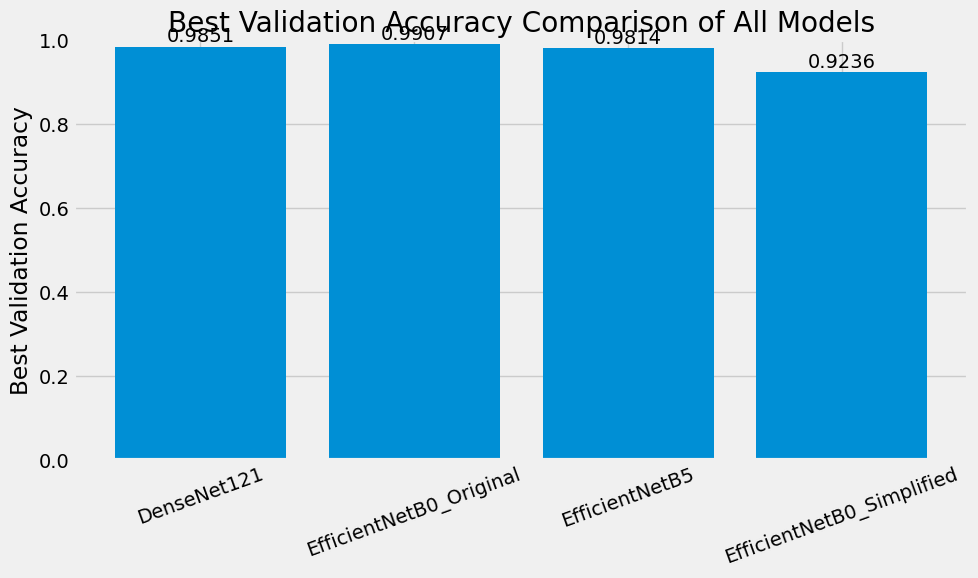

In [ ]:
import matplotlib.pyplot as plt

# Plot Test Accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df["Model"], comparison_df["Test_Accuracy"])
plt.title("Test Accuracy Comparison of All Models")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
for i, v in enumerate(comparison_df["Test_Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

# Plot Best Validation Accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df["Model"], comparison_df["Best_Val_Accuracy"])
plt.title("Best Validation Accuracy Comparison of All Models")
plt.ylabel("Best Validation Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
for i, v in enumerate(comparison_df["Best_Val_Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = comparison_df.loc[0, "Model"]
print("Selected best model for hyperparameter tuning:", best_model_name)

Selected best model for hyperparameter tuning: DenseNet121


## 6. Hyperparameter Tuning

**Hyperparameters** are settings chosen before training, such as learning rate, dropout rate, or dense-layer size. They are not learned directly from the data in the same way as weights.

### Why tuning is done after model selection
Instead of tuning every architecture, this notebook first picks the most promising model and tunes that candidate. This is a practical decision because it keeps the experiment focused and avoids unnecessary computation.

### Decision rationale for tuning

Tuning is used here to answer a specific question: can the selected baseline be improved through better training settings without redesigning the full architecture?  
This keeps the project organized because architecture comparison comes first and optimization comes second.

In [ ]:
!pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.1 MB/s eta 0:00:00


In [ ]:
!pip install -q keras-tuner
import keras_tuner as kt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

class_count = len(train_gen.class_indices)

def build_effnetb0_tuner(hp):
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
        pooling='avg'
    )

    # Keep backbone frozen for low complexity
    base_model.trainable = False

    model = Sequential()
    model.add(base_model)

    # Tunable dropout before dense
    model.add(Dropout(
        hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)
    ))

    # Tunable dense layer size
    model.add(Dense(
        units=hp.Choice('dense_units', values=[64, 128, 256]),
        activation='relu'
    ))

    # Tunable dropout after dense
    model.add(Dropout(
        hp.Float('dropout_2', min_value=0.1, max_value=0.4, step=0.1)
    ))

    # Output layer
    model.add(Dense(class_count, activation='softmax'))

    # Tunable learning rate
    lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=Adamax(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner_b0 = kt.RandomSearch(
    build_effnetb0_tuner,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='efficientnetb0_simplified_tuning'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

tuner_b0.search(
    train_gen,
    validation_data=valid_gen,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

best_hps_b0 = tuner_b0.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print("dense_units:", best_hps_b0.get('dense_units'))
print("dropout_1:", best_hps_b0.get('dropout_1'))
print("dropout_2:", best_hps_b0.get('dropout_2'))
print("learning_rate:", best_hps_b0.get('learning_rate'))

best_tuned_model = tuner_b0.hypermodel.build(best_hps_b0)

Trial 5 Complete [00h 03m 33s]
val_accuracy: 0.7723880410194397

Best val_accuracy So Far: 0.7723880410194397
Total elapsed time: 00h 34m 25s
Best hyperparameters found:
dense_units: 256
dropout_1: 0.2
dropout_2: 0.1
learning_rate: 0.0005


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

best_tuned_history = best_tuned_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.2043 - loss: 2.4455

KeyboardInterrupt: 

In [ ]:
plot_history(efficientnet_tuned_history)plot_history(best_tuned_history)

test_loss_tuned, test_acc_tuned = best_tuned_model.evaluate(test_gen, verbose=0)

print(f"Tuned model test loss: {test_loss_tuned:.4f}")
print(f"Tuned model test accuracy: {test_acc_tuned:.4f}")

plot_confusion_matrix(best_tuned_model, test_gen, title="Confusion Matrix - Tuned Best Model")
evaluate_model_performance(best_tuned_model, test_gen)

In [ ]:
best_untuned_name = comparison_df.loc[0, "Model"]

model_lookup = {
    "EfficientNetB0_Original": efficientNet_model_b0,
    "EfficientNetB0_Simplified": efficientNet_model_b0R,
    "EfficientNetB5": efficientNet_model_b5,
    "DenseNet121": densenet121_model
}

best_untuned_model = model_lookup[best_untuned_name]
best_untuned_loss, best_untuned_acc = best_untuned_model.evaluate(test_gen, verbose=0)

comparison_tuned_df = pd.DataFrame({
    "Model": [f"{best_untuned_name}_Untuned", "Best_Tuned_Model"],
    "Test_Accuracy": [best_untuned_acc, test_acc_tuned],
    "Test_Loss": [best_untuned_loss, test_loss_tuned]
})

display(comparison_tuned_df)

plt.figure(figsize=(8, 5))
plt.bar(comparison_tuned_df["Model"], comparison_tuned_df["Test_Accuracy"])
plt.title("Best Untuned Model vs Tuned Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(comparison_tuned_df["Test_Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()

## 7. External Testing on a Different Dataset

A strong internal test score does not automatically guarantee that a model will perform equally well on new data collected under different conditions.

### Why external testing matters
In medical imaging, **external validation** is important because models often lose performance when they are tested on data from a different source. For that reason, this notebook evaluates the selected architectures on a second brain-tumor MRI dataset to assess generalization more realistically.

### External validation note

A model may look strong on an internal test split yet weaken on a different dataset because image distributions, acquisition settings, labeling practices, or class proportions can differ. External testing therefore provides a more honest view of robustness.

In this project, one important explanation for the **very low accuracy on the external dataset** is that many MRI samples appear to be captured in **different directions/orientations** from those seen in the original training dataset. In other words, the model was trained on one visual distribution, then evaluated on another one with a different anatomical view presentation. This kind of **domain shift** can make learned features less transferable and can strongly reduce performance even when the pathology classes are similar.


### External test A — EfficientNetB0 simplified

The following block evaluates the simplified EfficientNetB0 model on a separate external dataset. This helps determine whether the lighter task-specific head remains robust outside the original data split.

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
Using external dataset folder: /kaggle/input/brain-tumor-mri-dataset/Testing

Original training classes:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Requested label mapping:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}

Valid label mapping used:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}
Skipping folder 'pituitary' because it is not mapped.

External dataset size after mapping: 1200

External label distribution:
labels
_NORMAL         400
Meningioma      400
Glioblastoma    400
Name: count, dtype: int64


,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL


Found 1200 validated image filenames belonging to 15 classes.

External generator class indices:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Evaluating EfficientNetB0_Simplified on external dataset (3-class view)

Using only these output classes:
Glioblastoma: class id 5
Meningioma: class id 8
_NORMAL: class id 14
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step

EfficientNetB0_Simplified - 3-Class External Accuracy: 0.4142

Classification Report - EfficientNetB0_Simplified:

              precision    recall  f1-score   support

Glioblastoma     0.2685    0.1450    0.1883       400
  Meningioma     0.3785    0.8025    0.5144       400
     _NORMAL     0.8676    0.2950    0.4403       400

    accuracy                         0.4142      1200
   macro avg     0.5049    0

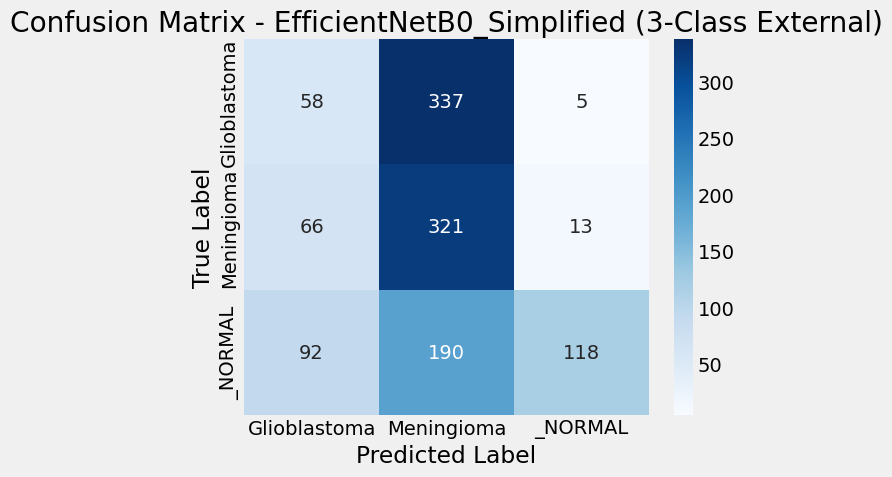


Predicted class distribution (3-class view):
Glioblastoma: 216
Meningioma: 848
_NORMAL: 136

External testing result:


,Model,3-Class External Accuracy
0,EfficientNetB0_Simplified,0.414167


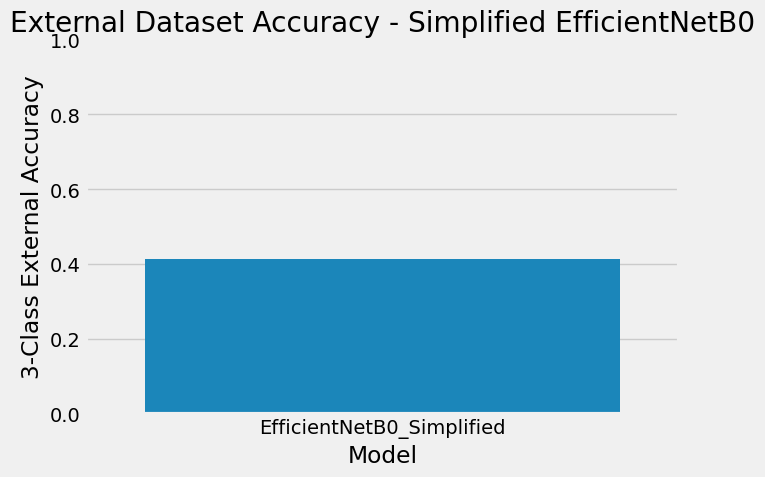

In [ ]:

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator



model_to_test = efficientNet_model_b0R
model_name = "EfficientNetB0_Simplified"


path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", path)

possible_folders = [
    os.path.join(path, "Testing"),
    os.path.join(path, "Training"),
    path
]

external_dataset_root = None
for folder in possible_folders:
    if os.path.exists(folder):
        subdirs = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))]
        if len(subdirs) > 0:
            external_dataset_root = folder
            break

if external_dataset_root is None:
    raise FileNotFoundError("Could not find a valid external dataset folder.")

print("Using external dataset folder:", external_dataset_root)


original_class_names = list(train_gen.class_indices.keys())
print("\nOriginal training classes:")
print(train_gen.class_indices)


new_to_original_label_map = {
    "glioma": "Glioblastoma",
    "meningioma": "Meningioma",
    "notumor": "_NORMAL"
}

print("\nRequested label mapping:")
print(new_to_original_label_map)

filtered_label_map = {}
for new_label, old_label in new_to_original_label_map.items():
    if old_label in original_class_names:
        filtered_label_map[new_label] = old_label
    else:
        print(f"Skipping mapping '{new_label} -> {old_label}' because '{old_label}' is not in the original training classes.")

if len(filtered_label_map) == 0:
    raise ValueError("No valid label mappings found between the external dataset and the original training classes.")

print("\nValid label mapping used:")
print(filtered_label_map)


filepaths_external = []
labels_external = []

for folder_name in os.listdir(external_dataset_root):
    folder_path = os.path.join(external_dataset_root, folder_name)

    if not os.path.isdir(folder_path):
        continue

    if folder_name not in filtered_label_map:
        print(f"Skipping folder '{folder_name}' because it is not mapped.")
        continue

    mapped_label = filtered_label_map[folder_name]

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        if os.path.isfile(fpath) and fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            filepaths_external.append(fpath)
            labels_external.append(mapped_label)

external_df = pd.DataFrame({
    "filepaths": filepaths_external,
    "labels": labels_external
})

if len(external_df) == 0:
    raise ValueError("No images found for the mapped classes in the external dataset.")

print("\nExternal dataset size after mapping:", len(external_df))
print("\nExternal label distribution:")
print(external_df["labels"].value_counts())

display(external_df.head())


external_datagen = ImageDataGenerator()

external_test_gen = external_datagen.flow_from_dataframe(
    dataframe=external_df,
    x_col="filepaths",
    y_col="labels",
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
    classes=original_class_names
)

print("\nExternal generator class indices:")
print(external_test_gen.class_indices)


def evaluate_model_on_external_dataset_3class(model, model_name, generator):
    print("\n" + "="*70)
    print(f"Evaluating {model_name} on external dataset (3-class view)")
    print("="*70)

    steps = math.ceil(generator.samples / generator.batch_size)

    target_classes = ["Glioblastoma", "Meningioma", "_NORMAL"]

    for c in target_classes:
        if c not in generator.class_indices:
            raise ValueError(f"Class '{c}' is not present in generator.class_indices. Check your mapping.")

    target_ids = [generator.class_indices[c] for c in target_classes]

    print("\nUsing only these output classes:")
    for c, i in zip(target_classes, target_ids):
        print(f"{c}: class id {i}")

    generator.reset()
    y_pred_probs = model.predict(generator, steps=steps, verbose=1)

    y_true_full = np.array(generator.classes)

    keep_mask = np.isin(y_true_full, target_ids)
    y_true_full = y_true_full[keep_mask]
    y_pred_probs = y_pred_probs[keep_mask]

    y_pred_probs_3 = y_pred_probs[:, target_ids]
    y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

    id_to_3class_index = {orig_id: new_idx for new_idx, orig_id in enumerate(target_ids)}
    y_true_3 = np.array([id_to_3class_index[y] for y in y_true_full])

    acc = accuracy_score(y_true_3, y_pred_3)
    print(f"\n{model_name} - 3-Class External Accuracy: {acc:.4f}")

    print(f"\nClassification Report - {model_name}:\n")
    print(
        classification_report(
            y_true_3,
            y_pred_3,
            labels=[0, 1, 2],
            target_names=target_classes,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true_3, y_pred_3, labels=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_classes,
        yticklabels=target_classes
    )
    plt.title(f"Confusion Matrix - {model_name} (3-Class External)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    pred_counts = pd.Series(y_pred_3).value_counts().sort_index()
    print("\nPredicted class distribution (3-class view):")
    for idx, count in pred_counts.items():
        print(f"{target_classes[idx]}: {count}")

    return {
        "Model": model_name,
        "3-Class External Accuracy": acc
    }


external_result = evaluate_model_on_external_dataset_3class(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen
)


external_result_df = pd.DataFrame([external_result])

print("\nExternal testing result:")
display(external_result_df)

plt.figure(figsize=(7, 5))
sns.barplot(data=external_result_df, x="Model", y="3-Class External Accuracy")
plt.title("External Dataset Accuracy - Simplified EfficientNetB0")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### External test B — EfficientNetB0 baseline

This block evaluates the baseline EfficientNetB0 model on the same external dataset so that its generalization can be compared fairly against the simplified variant and the larger backbones.

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
Using external dataset folder: /kaggle/input/brain-tumor-mri-dataset/Testing

Original training classes:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Requested label mapping:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}

Valid label mapping used:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}
Skipping folder 'pituitary' because it is not mapped.

External dataset size after mapping: 1200

External label distribution:
labels
_NORMAL         400
Meningioma      400
Glioblastoma    400
Name: count, dtype: int64


,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL


Found 1200 validated image filenames belonging to 15 classes.

External generator class indices:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Evaluating EfficientNetB0 on external dataset (3-class view)

Using only these output classes:
Glioblastoma: class id 5
Meningioma: class id 8
_NORMAL: class id 14
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 636ms/step

EfficientNetB0 - 3-Class External Accuracy: 0.4992

Classification Report - EfficientNetB0:

              precision    recall  f1-score   support

Glioblastoma     0.5354    0.2650    0.3545       400
  Meningioma     0.4024    0.8300    0.5420       400
     _NORMAL     0.9096    0.4025    0.5581       400

    accuracy                         0.4992      1200
   macro avg     0.6158    0.4992    0.4849      1200
weig

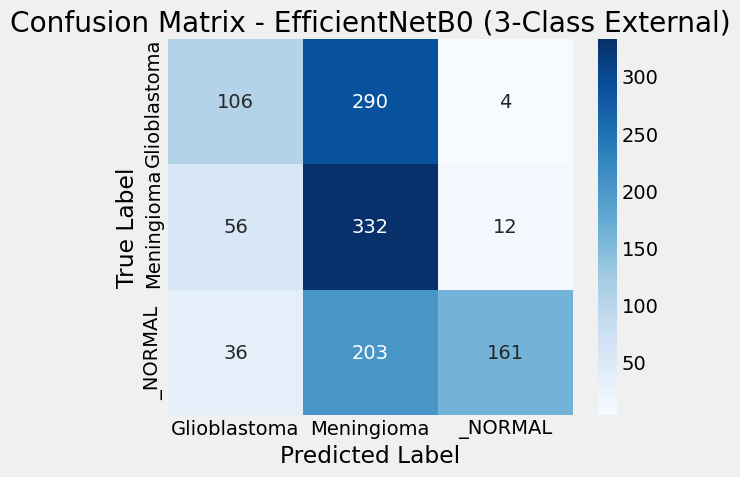


Predicted class distribution (3-class view):
Glioblastoma: 198
Meningioma: 825
_NORMAL: 177

External testing result:


,Model,3-Class External Accuracy
0,EfficientNetB0,0.499167


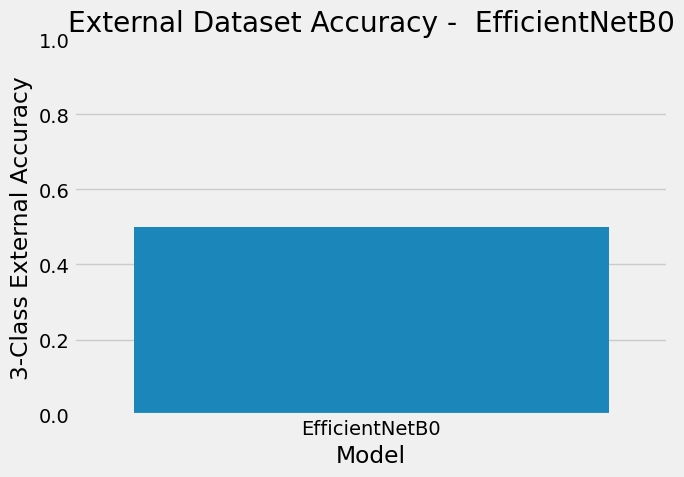

In [ ]:

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator


model_to_test = efficientNet_model_b0
model_name = "EfficientNetB0"


path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", path)

possible_folders = [
    os.path.join(path, "Testing"),
    os.path.join(path, "Training"),
    path
]

external_dataset_root = None
for folder in possible_folders:
    if os.path.exists(folder):
        subdirs = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))]
        if len(subdirs) > 0:
            external_dataset_root = folder
            break

if external_dataset_root is None:
    raise FileNotFoundError("Could not find a valid external dataset folder.")

print("Using external dataset folder:", external_dataset_root)

original_class_names = list(train_gen.class_indices.keys())
print("\nOriginal training classes:")
print(train_gen.class_indices)


new_to_original_label_map = {
    "glioma": "Glioblastoma",
    "meningioma": "Meningioma",
    "notumor": "_NORMAL"
}

print("\nRequested label mapping:")
print(new_to_original_label_map)

filtered_label_map = {}
for new_label, old_label in new_to_original_label_map.items():
    if old_label in original_class_names:
        filtered_label_map[new_label] = old_label
    else:
        print(f"Skipping mapping '{new_label} -> {old_label}' because '{old_label}' is not in the original training classes.")

if len(filtered_label_map) == 0:
    raise ValueError("No valid label mappings found between the external dataset and the original training classes.")

print("\nValid label mapping used:")
print(filtered_label_map)


filepaths_external = []
labels_external = []

for folder_name in os.listdir(external_dataset_root):
    folder_path = os.path.join(external_dataset_root, folder_name)

    if not os.path.isdir(folder_path):
        continue

    if folder_name not in filtered_label_map:
        print(f"Skipping folder '{folder_name}' because it is not mapped.")
        continue

    mapped_label = filtered_label_map[folder_name]

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        if os.path.isfile(fpath) and fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            filepaths_external.append(fpath)
            labels_external.append(mapped_label)

external_df = pd.DataFrame({
    "filepaths": filepaths_external,
    "labels": labels_external
})

if len(external_df) == 0:
    raise ValueError("No images found for the mapped classes in the external dataset.")

print("\nExternal dataset size after mapping:", len(external_df))
print("\nExternal label distribution:")
print(external_df["labels"].value_counts())

display(external_df.head())

external_datagen = ImageDataGenerator()

external_test_gen = external_datagen.flow_from_dataframe(
    dataframe=external_df,
    x_col="filepaths",
    y_col="labels",
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
    classes=original_class_names
)

print("\nExternal generator class indices:")
print(external_test_gen.class_indices)


def evaluate_model_on_external_dataset_3class(model, model_name, generator):
    print("\n" + "="*70)
    print(f"Evaluating {model_name} on external dataset (3-class view)")
    print("="*70)

    steps = math.ceil(generator.samples / generator.batch_size)

    target_classes = ["Glioblastoma", "Meningioma", "_NORMAL"]

    for c in target_classes:
        if c not in generator.class_indices:
            raise ValueError(f"Class '{c}' is not present in generator.class_indices. Check your mapping.")

    target_ids = [generator.class_indices[c] for c in target_classes]

    print("\nUsing only these output classes:")
    for c, i in zip(target_classes, target_ids):
        print(f"{c}: class id {i}")

    generator.reset()
    y_pred_probs = model.predict(generator, steps=steps, verbose=1)

    y_true_full = np.array(generator.classes)

    keep_mask = np.isin(y_true_full, target_ids)
    y_true_full = y_true_full[keep_mask]
    y_pred_probs = y_pred_probs[keep_mask]

    y_pred_probs_3 = y_pred_probs[:, target_ids]
    y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

    id_to_3class_index = {orig_id: new_idx for new_idx, orig_id in enumerate(target_ids)}
    y_true_3 = np.array([id_to_3class_index[y] for y in y_true_full])

    acc = accuracy_score(y_true_3, y_pred_3)
    print(f"\n{model_name} - 3-Class External Accuracy: {acc:.4f}")

    print(f"\nClassification Report - {model_name}:\n")
    print(
        classification_report(
            y_true_3,
            y_pred_3,
            labels=[0, 1, 2],
            target_names=target_classes,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true_3, y_pred_3, labels=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_classes,
        yticklabels=target_classes
    )
    plt.title(f"Confusion Matrix - {model_name} (3-Class External)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    pred_counts = pd.Series(y_pred_3).value_counts().sort_index()
    print("\nPredicted class distribution (3-class view):")
    for idx, count in pred_counts.items():
        print(f"{target_classes[idx]}: {count}")

    return {
        "Model": model_name,
        "3-Class External Accuracy": acc
    }


external_result = evaluate_model_on_external_dataset_3class(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen
)


external_result_df = pd.DataFrame([external_result])

print("\nExternal testing result:")
display(external_result_df)

plt.figure(figsize=(7, 5))
sns.barplot(data=external_result_df, x="Model", y="3-Class External Accuracy")
plt.title("External Dataset Accuracy -  EfficientNetB0")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### External test C — EfficientNetB5



Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
Using external dataset folder: /kaggle/input/brain-tumor-mri-dataset/Testing

Original training classes:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Requested label mapping:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}

Valid label mapping used:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}
Skipping folder 'pituitary' because it is not mapped.

External dataset size after mapping: 1200

External label distribution:
labels
_NORMAL         400
Meningioma      400
Glioblastoma    400
Name: count, dtype: int64


,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL


Found 1200 validated image filenames belonging to 15 classes.

External generator class indices:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Evaluating EfficientNetB5 on external dataset (3-class view)

Using only these output classes:
Glioblastoma: class id 5
Meningioma: class id 8
_NORMAL: class id 14
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step

EfficientNetB5 - 3-Class External Accuracy: 0.3992

Classification Report - EfficientNetB5:

              precision    recall  f1-score   support

Glioblastoma     0.3067    0.2500    0.2755       400
  Meningioma     0.4023    0.8025    0.5359       400
     _NORMAL     0.7632    0.1450    0.2437       400

    accuracy                         0.3992      1200
   macro avg     0.4907    0.3992    0.3517      1200
weighte

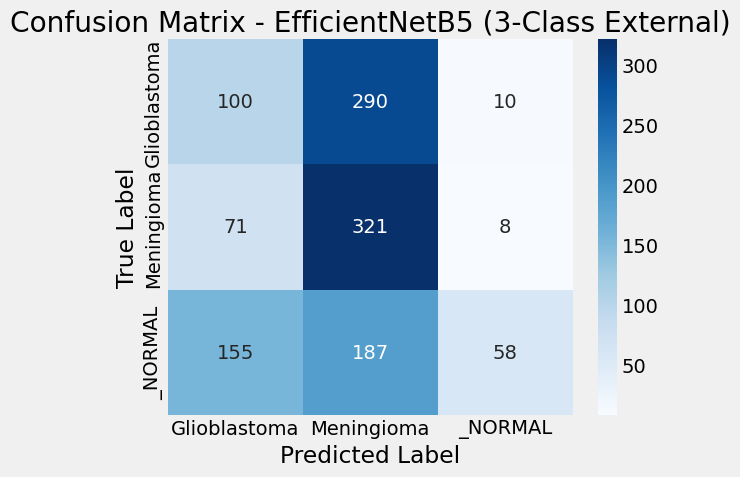


Predicted class distribution (3-class view):
Glioblastoma: 326
Meningioma: 798
_NORMAL: 76

External testing result:


,Model,3-Class External Accuracy
0,EfficientNetB5,0.399167


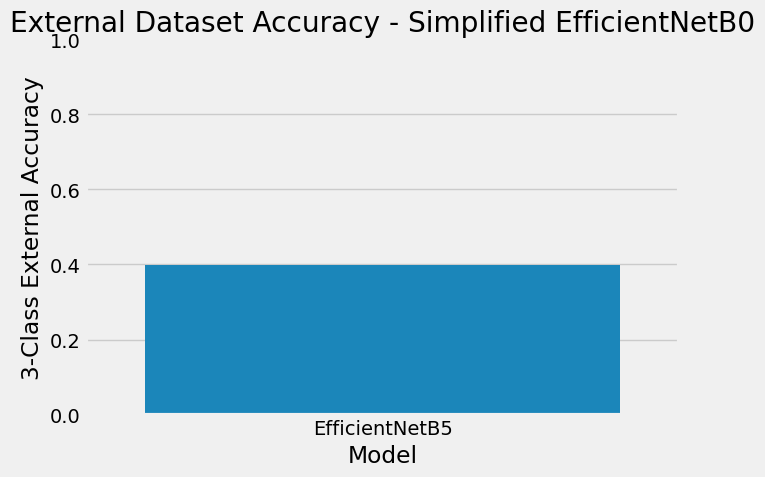

In [ ]:

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator



model_to_test = efficientNet_model_b5
model_name = "EfficientNetB5"


path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", path)

possible_folders = [
    os.path.join(path, "Testing"),
    os.path.join(path, "Training"),
    path
]

external_dataset_root = None
for folder in possible_folders:
    if os.path.exists(folder):
        subdirs = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))]
        if len(subdirs) > 0:
            external_dataset_root = folder
            break

if external_dataset_root is None:
    raise FileNotFoundError("Could not find a valid external dataset folder.")

print("Using external dataset folder:", external_dataset_root)


original_class_names = list(train_gen.class_indices.keys())
print("\nOriginal training classes:")
print(train_gen.class_indices)


new_to_original_label_map = {
    "glioma": "Glioblastoma",
    "meningioma": "Meningioma",
    "notumor": "_NORMAL"
}

print("\nRequested label mapping:")
print(new_to_original_label_map)

filtered_label_map = {}
for new_label, old_label in new_to_original_label_map.items():
    if old_label in original_class_names:
        filtered_label_map[new_label] = old_label
    else:
        print(f"Skipping mapping '{new_label} -> {old_label}' because '{old_label}' is not in the original training classes.")

if len(filtered_label_map) == 0:
    raise ValueError("No valid label mappings found between the external dataset and the original training classes.")

print("\nValid label mapping used:")
print(filtered_label_map)


filepaths_external = []
labels_external = []

for folder_name in os.listdir(external_dataset_root):
    folder_path = os.path.join(external_dataset_root, folder_name)

    if not os.path.isdir(folder_path):
        continue

    if folder_name not in filtered_label_map:
        print(f"Skipping folder '{folder_name}' because it is not mapped.")
        continue

    mapped_label = filtered_label_map[folder_name]

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        if os.path.isfile(fpath) and fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            filepaths_external.append(fpath)
            labels_external.append(mapped_label)

external_df = pd.DataFrame({
    "filepaths": filepaths_external,
    "labels": labels_external
})

if len(external_df) == 0:
    raise ValueError("No images found for the mapped classes in the external dataset.")

print("\nExternal dataset size after mapping:", len(external_df))
print("\nExternal label distribution:")
print(external_df["labels"].value_counts())

display(external_df.head())


external_datagen = ImageDataGenerator()

external_test_gen = external_datagen.flow_from_dataframe(
    dataframe=external_df,
    x_col="filepaths",
    y_col="labels",
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
    classes=original_class_names
)

print("\nExternal generator class indices:")
print(external_test_gen.class_indices)


def evaluate_model_on_external_dataset_3class(model, model_name, generator):
    print("\n" + "="*70)
    print(f"Evaluating {model_name} on external dataset (3-class view)")
    print("="*70)

    steps = math.ceil(generator.samples / generator.batch_size)

    target_classes = ["Glioblastoma", "Meningioma", "_NORMAL"]

    for c in target_classes:
        if c not in generator.class_indices:
            raise ValueError(f"Class '{c}' is not present in generator.class_indices. Check your mapping.")

    target_ids = [generator.class_indices[c] for c in target_classes]

    print("\nUsing only these output classes:")
    for c, i in zip(target_classes, target_ids):
        print(f"{c}: class id {i}")

    generator.reset()
    y_pred_probs = model.predict(generator, steps=steps, verbose=1)

    y_true_full = np.array(generator.classes)

    keep_mask = np.isin(y_true_full, target_ids)
    y_true_full = y_true_full[keep_mask]
    y_pred_probs = y_pred_probs[keep_mask]

    y_pred_probs_3 = y_pred_probs[:, target_ids]
    y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

    id_to_3class_index = {orig_id: new_idx for new_idx, orig_id in enumerate(target_ids)}
    y_true_3 = np.array([id_to_3class_index[y] for y in y_true_full])

    acc = accuracy_score(y_true_3, y_pred_3)
    print(f"\n{model_name} - 3-Class External Accuracy: {acc:.4f}")

    print(f"\nClassification Report - {model_name}:\n")
    print(
        classification_report(
            y_true_3,
            y_pred_3,
            labels=[0, 1, 2],
            target_names=target_classes,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true_3, y_pred_3, labels=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_classes,
        yticklabels=target_classes
    )
    plt.title(f"Confusion Matrix - {model_name} (3-Class External)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    pred_counts = pd.Series(y_pred_3).value_counts().sort_index()
    print("\nPredicted class distribution (3-class view):")
    for idx, count in pred_counts.items():
        print(f"{target_classes[idx]}: {count}")

    return {
        "Model": model_name,
        "3-Class External Accuracy": acc
    }

external_result = evaluate_model_on_external_dataset_3class(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen
)


external_result_df = pd.DataFrame([external_result])

print("\nExternal testing result:")
display(external_result_df)

plt.figure(figsize=(7, 5))
sns.barplot(data=external_result_df, x="Model", y="3-Class External Accuracy")
plt.title("External Dataset Accuracy - Simplified EfficientNetB0")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### External test D — DenseNet121



Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
Using external dataset folder: /kaggle/input/brain-tumor-mri-dataset/Testing

Original training classes:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Requested label mapping:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}

Valid label mapping used:
{'glioma': 'Glioblastoma', 'meningioma': 'Meningioma', 'notumor': '_NORMAL'}
Skipping folder 'pituitary' because it is not mapped.

External dataset size after mapping: 1200

External label distribution:
labels
_NORMAL         400
Meningioma      400
Glioblastoma    400
Name: count, dtype: int64


,filepaths,labels
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,_NORMAL


Found 1200 validated image filenames belonging to 15 classes.

External generator class indices:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}

Evaluating densenet121 on external dataset (3-class view)

Using only these output classes:
Glioblastoma: class id 5
Meningioma: class id 8
_NORMAL: class id 14
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step

densenet121 - 3-Class External Accuracy: 0.3467

Classification Report - densenet121:

              precision    recall  f1-score   support

Glioblastoma     0.2639    0.1425    0.1851       400
  Meningioma     0.3485    0.7675    0.4793       400
     _NORMAL     0.5049    0.1300    0.2068       400

    accuracy                         0.3467      1200
   macro avg     0.3724    0.3467    0.2904      1200
weighted avg    

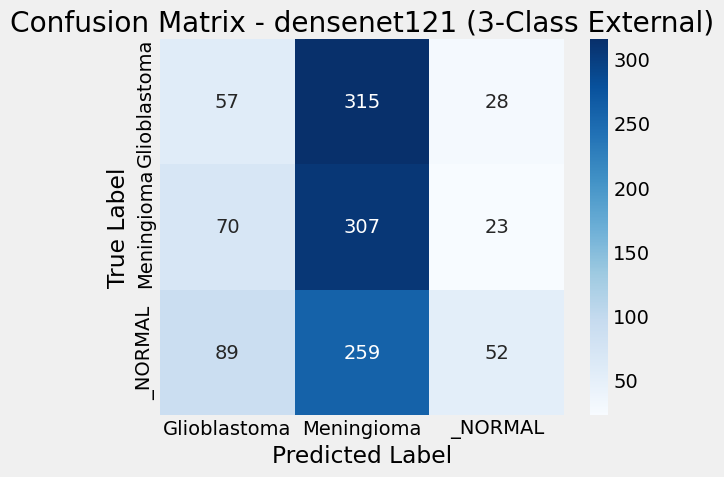


Predicted class distribution (3-class view):
Glioblastoma: 216
Meningioma: 881
_NORMAL: 103

External testing result:


,Model,3-Class External Accuracy
0,densenet121,0.346667


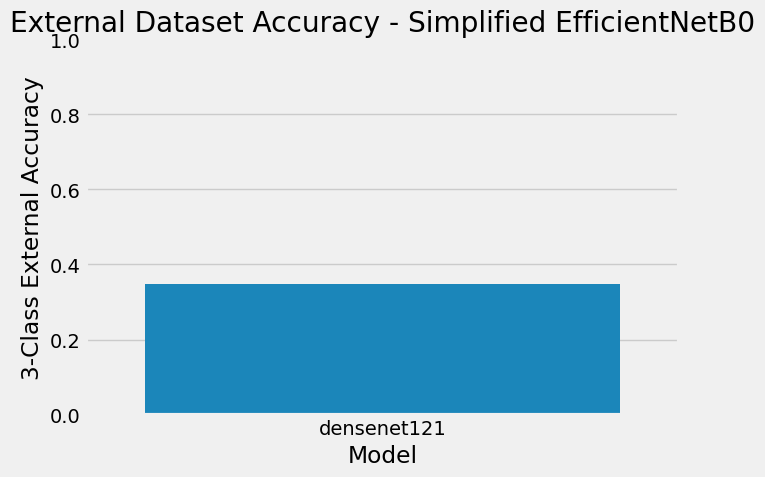

In [ ]:

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator


model_to_test = densenet121_model
model_name = "densenet121"


path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", path)

possible_folders = [
    os.path.join(path, "Testing"),
    os.path.join(path, "Training"),
    path
]

external_dataset_root = None
for folder in possible_folders:
    if os.path.exists(folder):
        subdirs = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))]
        if len(subdirs) > 0:
            external_dataset_root = folder
            break

if external_dataset_root is None:
    raise FileNotFoundError("Could not find a valid external dataset folder.")

print("Using external dataset folder:", external_dataset_root)


original_class_names = list(train_gen.class_indices.keys())
print("\nOriginal training classes:")
print(train_gen.class_indices)


new_to_original_label_map = {
    "glioma": "Glioblastoma",
    "meningioma": "Meningioma",
    "notumor": "_NORMAL"
}

print("\nRequested label mapping:")
print(new_to_original_label_map)

filtered_label_map = {}
for new_label, old_label in new_to_original_label_map.items():
    if old_label in original_class_names:
        filtered_label_map[new_label] = old_label
    else:
        print(f"Skipping mapping '{new_label} -> {old_label}' because '{old_label}' is not in the original training classes.")

if len(filtered_label_map) == 0:
    raise ValueError("No valid label mappings found between the external dataset and the original training classes.")

print("\nValid label mapping used:")
print(filtered_label_map)


filepaths_external = []
labels_external = []

for folder_name in os.listdir(external_dataset_root):
    folder_path = os.path.join(external_dataset_root, folder_name)

    if not os.path.isdir(folder_path):
        continue

    if folder_name not in filtered_label_map:
        print(f"Skipping folder '{folder_name}' because it is not mapped.")
        continue

    mapped_label = filtered_label_map[folder_name]

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        if os.path.isfile(fpath) and fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            filepaths_external.append(fpath)
            labels_external.append(mapped_label)

external_df = pd.DataFrame({
    "filepaths": filepaths_external,
    "labels": labels_external
})

if len(external_df) == 0:
    raise ValueError("No images found for the mapped classes in the external dataset.")

print("\nExternal dataset size after mapping:", len(external_df))
print("\nExternal label distribution:")
print(external_df["labels"].value_counts())

display(external_df.head())


external_datagen = ImageDataGenerator()

external_test_gen = external_datagen.flow_from_dataframe(
    dataframe=external_df,
    x_col="filepaths",
    y_col="labels",
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
    classes=original_class_names
)

print("\nExternal generator class indices:")
print(external_test_gen.class_indices)


def evaluate_model_on_external_dataset_3class(model, model_name, generator):
    print("\n" + "="*70)
    print(f"Evaluating {model_name} on external dataset (3-class view)")
    print("="*70)

    steps = math.ceil(generator.samples / generator.batch_size)

    target_classes = ["Glioblastoma", "Meningioma", "_NORMAL"]

    for c in target_classes:
        if c not in generator.class_indices:
            raise ValueError(f"Class '{c}' is not present in generator.class_indices. Check your mapping.")

    target_ids = [generator.class_indices[c] for c in target_classes]

    print("\nUsing only these output classes:")
    for c, i in zip(target_classes, target_ids):
        print(f"{c}: class id {i}")

    generator.reset()
    y_pred_probs = model.predict(generator, steps=steps, verbose=1)

    y_true_full = np.array(generator.classes)

    keep_mask = np.isin(y_true_full, target_ids)
    y_true_full = y_true_full[keep_mask]
    y_pred_probs = y_pred_probs[keep_mask]

    y_pred_probs_3 = y_pred_probs[:, target_ids]
    y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

    id_to_3class_index = {orig_id: new_idx for new_idx, orig_id in enumerate(target_ids)}
    y_true_3 = np.array([id_to_3class_index[y] for y in y_true_full])

    acc = accuracy_score(y_true_3, y_pred_3)
    print(f"\n{model_name} - 3-Class External Accuracy: {acc:.4f}")

    print(f"\nClassification Report - {model_name}:\n")
    print(
        classification_report(
            y_true_3,
            y_pred_3,
            labels=[0, 1, 2],
            target_names=target_classes,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true_3, y_pred_3, labels=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_classes,
        yticklabels=target_classes
    )
    plt.title(f"Confusion Matrix - {model_name} (3-Class External)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    pred_counts = pd.Series(y_pred_3).value_counts().sort_index()
    print("\nPredicted class distribution (3-class view):")
    for idx, count in pred_counts.items():
        print(f"{target_classes[idx]}: {count}")

    return {
        "Model": model_name,
        "3-Class External Accuracy": acc
    }

external_result = evaluate_model_on_external_dataset_3class(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen
)

external_result_df = pd.DataFrame([external_result])

print("\nExternal testing result:")
display(external_result_df)

plt.figure(figsize=(7, 5))
sns.barplot(data=external_result_df, x="Model", y="3-Class External Accuracy")
plt.title("External Dataset Accuracy - Simplified EfficientNetB0")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### External dataset sample visualisation

The following section shows a small visual sample from the new MRI dataset used for external evaluation.  
This is useful because it allows the reader to qualitatively inspect the external data distribution and to notice practical differences such as scan direction, slice orientation, framing and contrast. In this project, some of the external MRI samples appear in different directions/orientations compared with the training data, which likely contributes to the domain shift and the lower external-test accuracy.

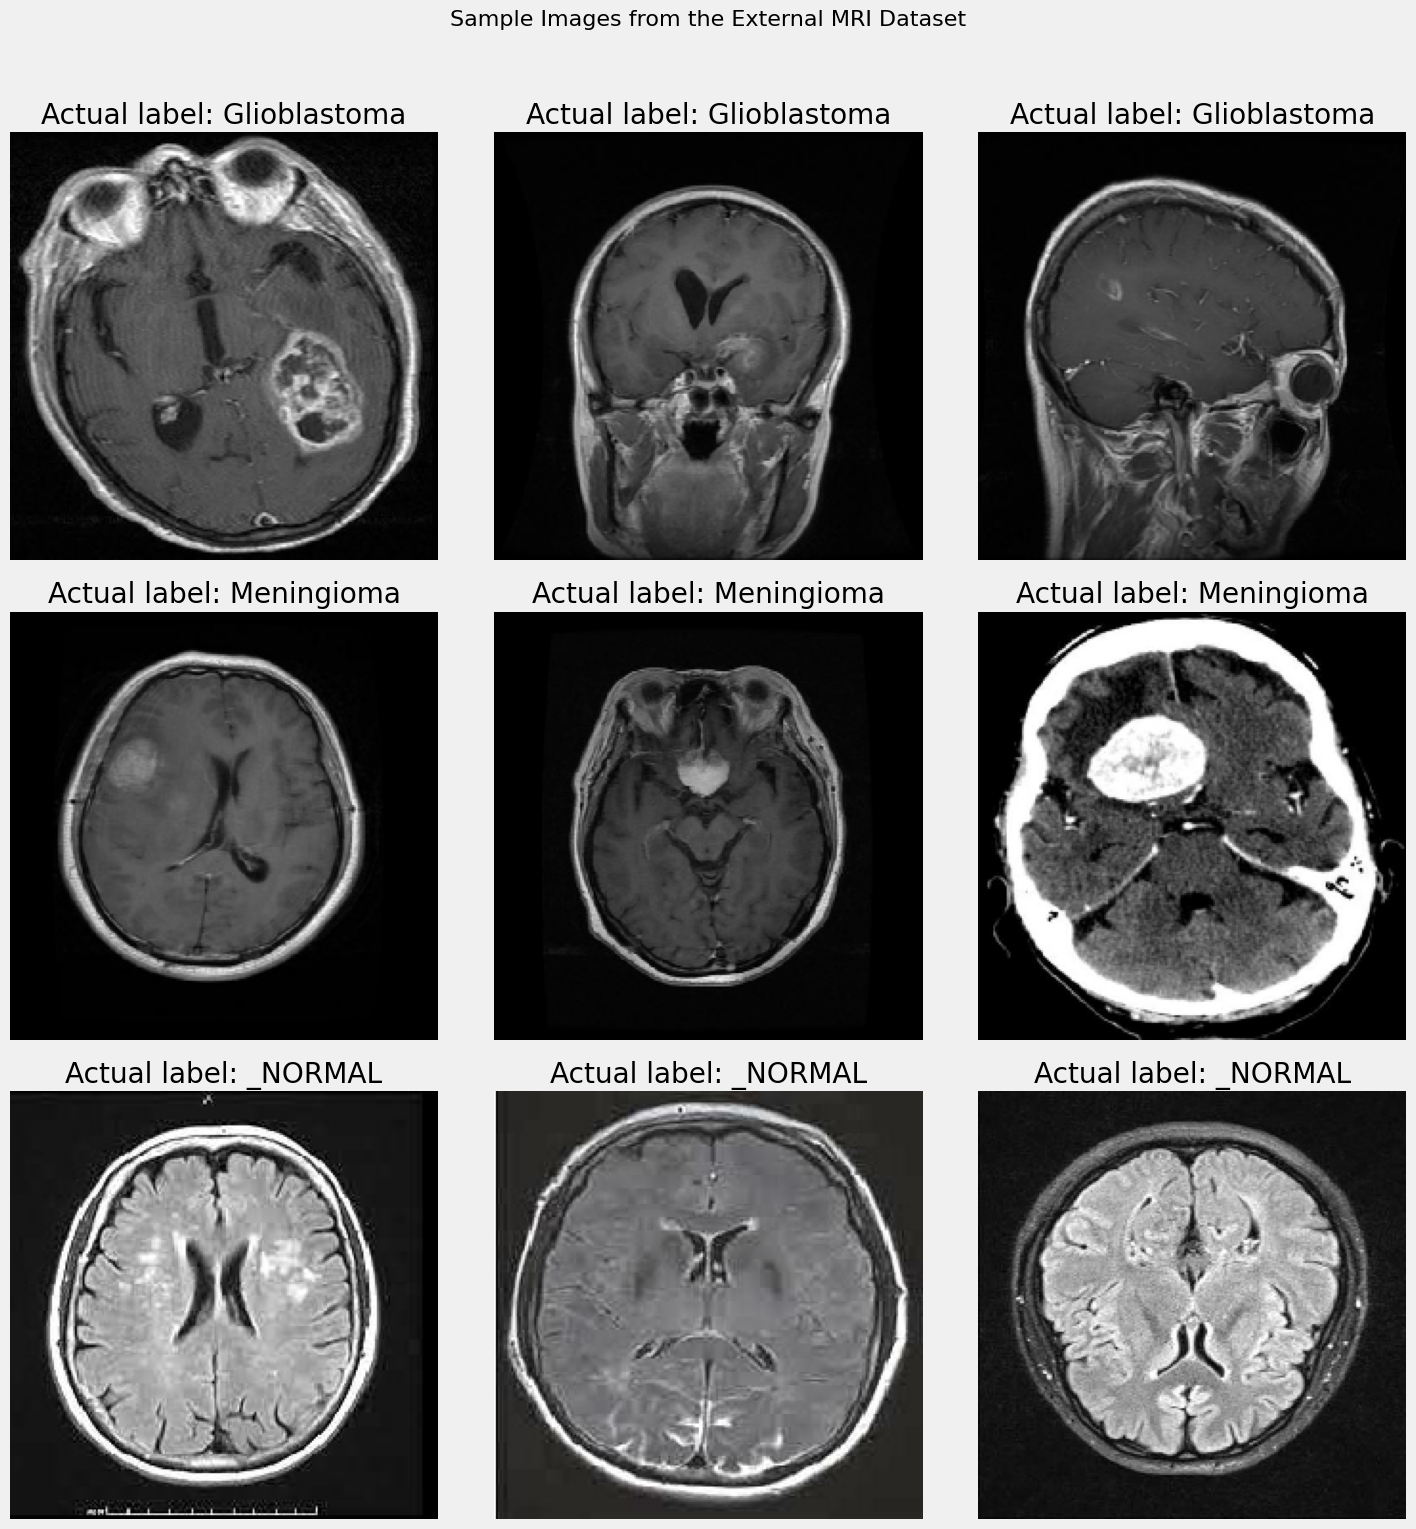

,labels,filepaths
0,Glioblastoma,/kaggle/input/brain-tumor-mri-dataset/Testing/...
1,Glioblastoma,/kaggle/input/brain-tumor-mri-dataset/Testing/...
2,Glioblastoma,/kaggle/input/brain-tumor-mri-dataset/Testing/...
3,Meningioma,/kaggle/input/brain-tumor-mri-dataset/Testing/...
4,Meningioma,/kaggle/input/brain-tumor-mri-dataset/Testing/...
5,Meningioma,/kaggle/input/brain-tumor-mri-dataset/Testing/...
6,_NORMAL,/kaggle/input/brain-tumor-mri-dataset/Testing/...
7,_NORMAL,/kaggle/input/brain-tumor-mri-dataset/Testing/...
8,_NORMAL,/kaggle/input/brain-tumor-mri-dataset/Testing/...


In [ ]:


import math
import random
from tensorflow.keras.preprocessing import image as keras_image

if "external_df" not in globals():
    raise ValueError("Run one of the external testing cells first so that external_df is created.")

sample_per_class = 3
random_state = 42

sample_df = (
    external_df.groupby("labels", group_keys=False)
    .apply(lambda x: x.sample(min(sample_per_class, len(x)), random_state=random_state))
    .reset_index(drop=True)
)

n_images = len(sample_df)
cols = 3
rows = math.ceil(n_images / cols)

plt.figure(figsize=(15, 5 * rows))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = keras_image.load_img(row["filepaths"], target_size=img_size)
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(f"Actual label: {row['labels']}")
    plt.axis("off")

plt.suptitle("Sample Images from the External MRI Dataset", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

display(sample_df[["labels", "filepaths"]])

# trying in new dataset

In [ ]:
# 2) load saved models
from google.colab import drive
from tensorflow.keras.models import load_model
import os

drive.mount('/content/drive')

model_files = []
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.keras') or file.endswith('.h5'):
            model_files.append(os.path.join(root, file))

print("Found model files:")
for f in model_files:
    print(f)

for f in model_files:
    fname = os.path.basename(f).lower()

    if 'b0r' in fname or 'efficientnet_model_b0r' in fname:
        efficientNet_model_b0R = load_model(f)
        print(f"Loaded efficientNet_model_b0R from {f}")

    elif 'b0' in fname and 'b0r' not in fname:
        efficientNet_model_b0 = load_model(f)
        print(f"Loaded efficientNet_model_b0 from {f}")

    elif 'b5' in fname:
        efficientNet_model_b5 = load_model(f)
        print(f"Loaded efficientNet_model_b5 from {f}")

    elif 'dense' in fname or 'densenet121' in fname:
        densenet121_model = load_model(f)
        print(f"Loaded densenet121_model from {f}")

print("\nDone loading available models.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found model files:
/content/drive/MyDrive/brain_tumor_project/models/efficientNet_model_b0R.keras
/content/drive/MyDrive/brain_tumor_project/models/efficientNet_model_b0.keras
/content/drive/MyDrive/brain_tumor_project/models/efficientNet_model_b5.keras
/content/drive/MyDrive/brain_tumor_project/models/densenet121_model.keras
Loaded efficientNet_model_b0R from /content/drive/MyDrive/brain_tumor_project/models/efficientNet_model_b0R.keras
Loaded efficientNet_model_b0 from /content/drive/MyDrive/brain_tumor_project/models/efficientNet_model_b0.keras
Loaded efficientNet_model_b5 from /content/drive/MyDrive/brain_tumor_project/models/efficientNet_model_b5.keras
Loaded densenet121_model from /content/drive/MyDrive/brain_tumor_project/models/densenet121_model.keras

Done loading available models.


### function


In [ ]:
import os
import math
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

EXTERNAL_DATASET_SLUG = "fernando2rad/brain-tumor-mri-images-17-classes"

def normalize_label_name(text):
    text = str(text)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = text.lower()
    text = text.replace("+", " plus ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_external_label_aliases():
    return {
        "Meningioma": ["meningioma"],
        "Astrocitoma": ["astrocitoma", "astrocytoma", "astrocitoma pilocitico"],
        "_NORMAL": ["normal", "no tumor", "notumor", "sem tumor", "saudavel", "healthy"],
        "Schwannoma": ["schwannoma", "neurinoma", "schwanoma"],
        "Neurocitoma": ["neurocitoma", "neurocytoma"],
        "Carcinoma": ["carcinoma"],
        "Papiloma": ["papiloma", "papilloma", "plexo coroide", "choroid plexus"],
        "Oligodendroglioma": ["oligodendroglioma"],
        "Glioblastoma": ["glioblastoma", "glioblastoma multiforme", "gbm"],
        "Ependimoma": ["ependimoma", "ependymoma"],
        "Tuberculoma": ["tuberculoma"],
        "Meduloblastoma": ["meduloblastoma", "medulloblastoma"],
        "Germinoma": ["germinoma"],
        "Granuloma": ["granuloma"],
        "Ganglioglioma": ["ganglioglioma"],
    }

def infer_project_label_from_folder(folder_name, original_class_names):
    norm_folder = normalize_label_name(folder_name)
    alias_map = build_external_label_aliases()

    for project_label in original_class_names:
        aliases = alias_map.get(project_label, [project_label])
        for alias in aliases:
            if normalize_label_name(alias) in norm_folder:
                return project_label
    return None

# make sure these already exist from your earlier notebook cells
print("Checking required variables...")
print("train_gen exists:", "train_gen" in globals())
print("img_size exists:", "img_size" in globals())
print("batch_size exists:", "batch_size" in globals())

original_class_names = list(train_gen.class_indices.keys())
print("\nOriginal training classes:")
print(train_gen.class_indices)

path = kagglehub.dataset_download(EXTERNAL_DATASET_SLUG)
print("\nDataset downloaded to:", path)

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
filepaths_external = []
labels_external = []
matched_rows = []
skipped_dirs = []

for root, dirs, files in os.walk(path):
    image_files = [f for f in files if f.lower().endswith(image_extensions)]

    if len(image_files) == 0:
        continue

    folder_name = os.path.basename(root)
    mapped_label = infer_project_label_from_folder(folder_name, original_class_names)

    if mapped_label is None:
        skipped_dirs.append(root)
        continue

    for fname in image_files:
        fpath = os.path.join(root, fname)
        filepaths_external.append(fpath)
        labels_external.append(mapped_label)

    matched_rows.append({
        "external_folder": folder_name,
        "mapped_project_label": mapped_label,
        "num_images": len(image_files)
    })

external_df = pd.DataFrame({
    "filepaths": filepaths_external,
    "labels": labels_external
})

if len(external_df) == 0:
    raise ValueError(
        "No images were matched. Check your train_gen.class_indices names and update the alias dictionary."
    )

external_mapping_df = (
    pd.DataFrame(matched_rows)
    .sort_values(["mapped_project_label", "external_folder"])
    .reset_index(drop=True)
)

print("\nMatched external folders:")
display(external_mapping_df)

print("\nExternal dataset size after matching:", len(external_df))
print("\nMatched external label distribution:")
print(external_df["labels"].value_counts())

if len(skipped_dirs) > 0:
    print(f"\nSkipped image folders with no mapping: {len(skipped_dirs)}")
    for d in skipped_dirs[:10]:
        print("-", d)
    if len(skipped_dirs) > 10:
        print("...")

external_datagen = ImageDataGenerator()

external_test_gen = external_datagen.flow_from_dataframe(
    dataframe=external_df,
    x_col="filepaths",
    y_col="labels",
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
    classes=original_class_names
)

print("\nexternal_test_gen created successfully")
print("Samples:", external_test_gen.samples)
print("Class indices:", external_test_gen.class_indices)

def evaluate_model_on_external_dataset_matched(model, model_name, generator, original_class_names, external_df):
    print("\n" + "=" * 70)
    print(f"Evaluating {model_name} on external dataset")
    print("=" * 70)

    steps = math.ceil(generator.samples / generator.batch_size)

    present_class_names = [
        class_name for class_name in original_class_names
        if class_name in set(external_df["labels"])
    ]

    if len(present_class_names) < 2:
        raise ValueError("At least two matched classes are required for evaluation.")

    present_ids = [generator.class_indices[c] for c in present_class_names]

    print("\nMatched classes used in evaluation:")
    for c, i in zip(present_class_names, present_ids):
        print(f"{c}: class id {i}")

    generator.reset()
    y_pred_probs = model.predict(generator, steps=steps, verbose=1)
    y_true_full = np.array(generator.classes)

    keep_mask = np.isin(y_true_full, present_ids)
    y_true_full = y_true_full[keep_mask]
    y_pred_probs = y_pred_probs[keep_mask]

    y_pred_probs_matched = y_pred_probs[:, present_ids]
    y_pred_matched = np.argmax(y_pred_probs_matched, axis=1)

    id_to_local_index = {orig_id: new_idx for new_idx, orig_id in enumerate(present_ids)}
    y_true_matched = np.array([id_to_local_index[y] for y in y_true_full])

    acc = accuracy_score(y_true_matched, y_pred_matched)
    print(f"\n{model_name} - External Accuracy: {acc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_true_matched,
        y_pred_matched,
        labels=list(range(len(present_class_names))),
        target_names=present_class_names,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(
        y_true_matched,
        y_pred_matched,
        labels=list(range(len(present_class_names)))
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=present_class_names,
        yticklabels=present_class_names
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Matched Classes": ", ".join(present_class_names),
        "Num Matched Classes": len(present_class_names),
        "External Samples": int(len(y_true_matched)),
        "Matched-Class External Accuracy": acc
    }

Checking required variables...
train_gen exists: True
img_size exists: True
batch_size exists: True

Original training classes:
{'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tuberculoma': 13, '_NORMAL': 14}
Using Colab cache for faster access to the 'brain-tumor-mri-images-17-classes' dataset.

Dataset downloaded to: /kaggle/input/brain-tumor-mri-images-17-classes

Matched external folders:


,external_folder,mapped_project_label,num_images
0,"Glioma (Astrocitoma, Ganglioglioma, Glioblasto...",Astrocitoma,459
1,"Glioma (Astrocitoma, Ganglioglioma, Glioblasto...",Astrocitoma,512
2,"Glioma (Astrocitoma, Ganglioglioma, Glioblasto...",Astrocitoma,346
3,"Meningioma (de Baixo Grau, Atípico, Anaplásico...",Meningioma,345
4,"Meningioma (de Baixo Grau, Atípico, Anaplásico...",Meningioma,625
5,"Meningioma (de Baixo Grau, Atípico, Anaplásico...",Meningioma,329
6,"Neurocitoma (Central - Intraventricular, Extra...",Neurocitoma,169
7,"Neurocitoma (Central - Intraventricular, Extra...",Neurocitoma,261
8,"Neurocitoma (Central - Intraventricular, Extra...",Neurocitoma,112
9,"Schwannoma (Acustico, Vestibular - Trigeminal) T1",Schwannoma,153



External dataset size after matching: 4191

Matched external label distribution:
labels
Astrocitoma    1317
Meningioma     1299
_NORMAL         563
Neurocitoma     542
Schwannoma      470
Name: count, dtype: int64

Skipped image folders with no mapping: 3
- /kaggle/input/brain-tumor-mri-images-17-classes/Outros Tipos de Lesões (Abscessos, Cistos, Encefalopatias Diversas) T2
- /kaggle/input/brain-tumor-mri-images-17-classes/Outros Tipos de Lesões (Abscessos, Cistos, Encefalopatias Diversas) T1C+
- /kaggle/input/brain-tumor-mri-images-17-classes/Outros Tipos de Lesões (Abscessos, Cistos, Encefalopatias Diversas) T1
Found 4158 validated image filenames belonging to 15 classes.

external_test_gen created successfully
Samples: 4158
Class indices: {'Astrocitoma': 0, 'Carcinoma': 1, 'Ependimoma': 2, 'Ganglioglioma': 3, 'Germinoma': 4, 'Glioblastoma': 5, 'Granuloma': 6, 'Meduloblastoma': 7, 'Meningioma': 8, 'Neurocitoma': 9, 'Oligodendroglioma': 10, 'Papiloma': 11, 'Schwannoma': 12, 'Tubercul

In [ ]:
import os
import math
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

PROJECT_TO_SUPERCLASS = {
    "Astrocitoma": "Glioma_Group",
    "Ganglioglioma": "Glioma_Group",
    "Glioblastoma": "Glioma_Group",
    "Oligodendroglioma": "Glioma_Group",
    "Ependimoma": "Glioma_Group",
    "Meningioma": "Meningioma",
    "Neurocitoma": "Neurocitoma",
    "Schwannoma": "Schwannoma",
    "_NORMAL": "_NORMAL",
    "Carcinoma": "Other_Lesions",
    "Papiloma": "Other_Lesions",
    "Tuberculoma": "Other_Lesions",
    "Meduloblastoma": "Other_Lesions",
    "Germinoma": "Other_Lesions",
    "Granuloma": "Other_Lesions",
}

def map_external_folder_to_superclass(folder_name):
    f = normalize_label_name(folder_name)

    if "glioma" in f:
        return "Glioma_Group"
    elif "meningioma" in f:
        return "Meningioma"
    elif "normal" in f:
        return "_NORMAL"
    elif "neurocitoma" in f or "neurocytoma" in f:
        return "Neurocitoma"
    elif "schwannoma" in f or "neurinoma" in f:
        return "Schwannoma"
    elif "outros tipos de lesoes" in f or "lesoes" in f or "lesions" in f:
        return "Other_Lesions"
    else:
        return None

def prepare_grouped_external_df(path):
    image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    rows = []

    for root, dirs, files in os.walk(path):
        image_files = [f for f in files if f.lower().endswith(image_extensions)]
        if not image_files:
            continue

        folder_name = os.path.basename(root)
        superclass = map_external_folder_to_superclass(folder_name)

        if superclass is None:
            continue

        for fname in image_files:
            rows.append({
                "filepaths": os.path.join(root, fname),
                "labels": superclass,
                "external_folder": folder_name
            })

    external_grouped_df = pd.DataFrame(rows)

    if len(external_grouped_df) == 0:
        raise ValueError("No grouped external samples were found.")

    return external_grouped_df

def evaluate_model_grouped_external(model, model_name, external_df, external_test_gen, original_class_names):
    print("\n" + "=" * 70)
    print(f"Grouped external evaluation for {model_name}")
    print("=" * 70)

    superclasses = sorted(external_df["labels"].unique())
    print("\nGrouped classes used:")
    print(superclasses)

    original_to_idx = external_test_gen.class_indices
    grouped_class_to_member_indices = {}

    for superclass in superclasses:
        member_indices = []
        for original_class in original_class_names:
            mapped_super = PROJECT_TO_SUPERCLASS.get(original_class, None)
            if mapped_super == superclass and original_class in original_to_idx:
                member_indices.append(original_to_idx[original_class])
        grouped_class_to_member_indices[superclass] = member_indices

    print("\nSuperclass to original-class indices:")
    for k, v in grouped_class_to_member_indices.items():
        print(k, "->", v)

    external_test_gen.reset()
    steps = math.ceil(external_test_gen.samples / external_test_gen.batch_size)
    y_pred_probs = model.predict(external_test_gen, steps=steps, verbose=1)
    y_true_original = np.array(external_test_gen.classes)

    true_original_class_names = [original_class_names[i] for i in y_true_original]
    y_true_group_names = [PROJECT_TO_SUPERCLASS.get(c, None) for c in true_original_class_names]

    valid_mask = np.array([g in superclasses for g in y_true_group_names])
    y_pred_probs = y_pred_probs[valid_mask]
    y_true_group_names = np.array(y_true_group_names)[valid_mask]

    grouped_probs = np.zeros((len(y_pred_probs), len(superclasses)))

    for j, superclass in enumerate(superclasses):
        member_indices = grouped_class_to_member_indices[superclass]
        if len(member_indices) > 0:
            grouped_probs[:, j] = y_pred_probs[:, member_indices].sum(axis=1)

    y_pred_group_idx = np.argmax(grouped_probs, axis=1)
    y_pred_group_names = np.array([superclasses[i] for i in y_pred_group_idx])

    superclass_to_idx = {c: i for i, c in enumerate(superclasses)}
    y_true_idx = np.array([superclass_to_idx[c] for c in y_true_group_names])
    y_pred_idx = np.array([superclass_to_idx[c] for c in y_pred_group_names])

    acc = accuracy_score(y_true_idx, y_pred_idx)
    print(f"\nGrouped External Accuracy: {acc:.4f}\n")

    print(classification_report(
        y_true_idx,
        y_pred_idx,
        target_names=superclasses,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(superclasses))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=superclasses, yticklabels=superclasses)
    plt.title(f"Grouped External Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame([{
        "Model": model_name,
        "Grouped External Accuracy": acc,
        "Grouped Classes": ", ".join(superclasses),
        "External Samples": len(y_true_idx)
    }])

### All models in one with all 15 clases

Grouped external label distribution:


,count
labels,
Glioma_Group,1317
Meningioma,1299
_NORMAL,563
Neurocitoma,542
Schwannoma,470
Other_Lesions,257



Grouped external evaluation for EfficientNetB0_Simplified

Grouped classes used:
['Glioma_Group', 'Meningioma', 'Neurocitoma', 'Other_Lesions', 'Schwannoma', '_NORMAL']

Superclass to original-class indices:
Glioma_Group -> [0, 2, 3, 5, 10]
Meningioma -> [8]
Neurocitoma -> [9]
Other_Lesions -> [1, 4, 6, 7, 11, 13]
Schwannoma -> [12]
_NORMAL -> [14]
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 270ms/step

Grouped External Accuracy: 0.8187

               precision    recall  f1-score   support

 Glioma_Group     0.8383    0.7952    0.8161      1284
   Meningioma     0.8525    0.7075    0.7732      1299
  Neurocitoma     0.8397    0.9280    0.8817       542
Other_Lesions     0.0000    0.0000    0.0000         0
   Schwannoma     0.8296    0.9426    0.8825       470
      _NORMAL     0.8870    0.9201    0.9032       563

     accuracy                         0.8187      4158
    macro avg     0.7078    0.7156    0.7095      4158
 weighted avg     0.8485    0.8187    0.8306      4158



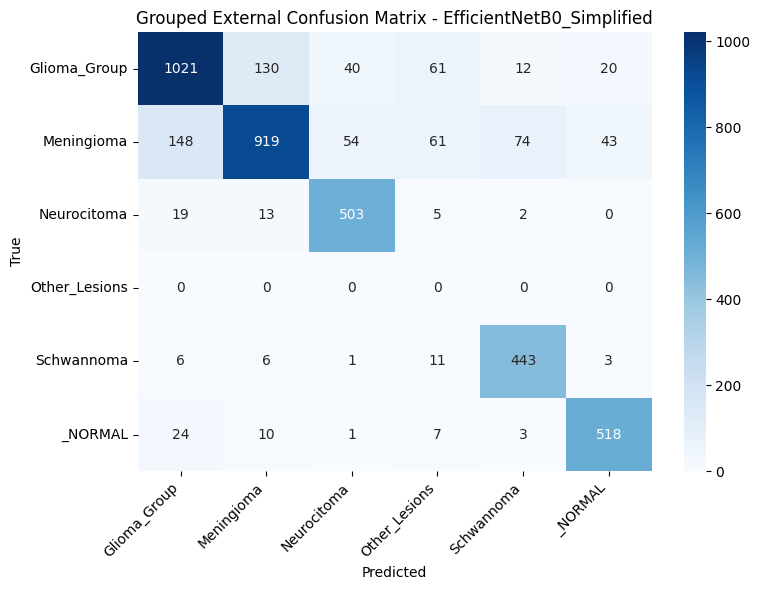


Grouped external evaluation for EfficientNetB0

Grouped classes used:
['Glioma_Group', 'Meningioma', 'Neurocitoma', 'Other_Lesions', 'Schwannoma', '_NORMAL']

Superclass to original-class indices:
Glioma_Group -> [0, 2, 3, 5, 10]
Meningioma -> [8]
Neurocitoma -> [9]
Other_Lesions -> [1, 4, 6, 7, 11, 13]
Schwannoma -> [12]
_NORMAL -> [14]
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step

Grouped External Accuracy: 0.8600

               precision    recall  f1-score   support

 Glioma_Group     0.9412    0.7726    0.8486      1284
   Meningioma     0.9024    0.8183    0.8583      1299
  Neurocitoma     0.8423    0.9852    0.9082       542
Other_Lesions     0.0000    0.0000    0.0000         0
   Schwannoma     0.7986    0.9957    0.8864       470
      _NORMAL     0.8979    0.9218    0.9097       563

     accuracy                         0.8600      4158
    macro avg     0.7304    0.7490    0.7352      4158
 weighted avg     0.8942    0.8600    0.8719      4158



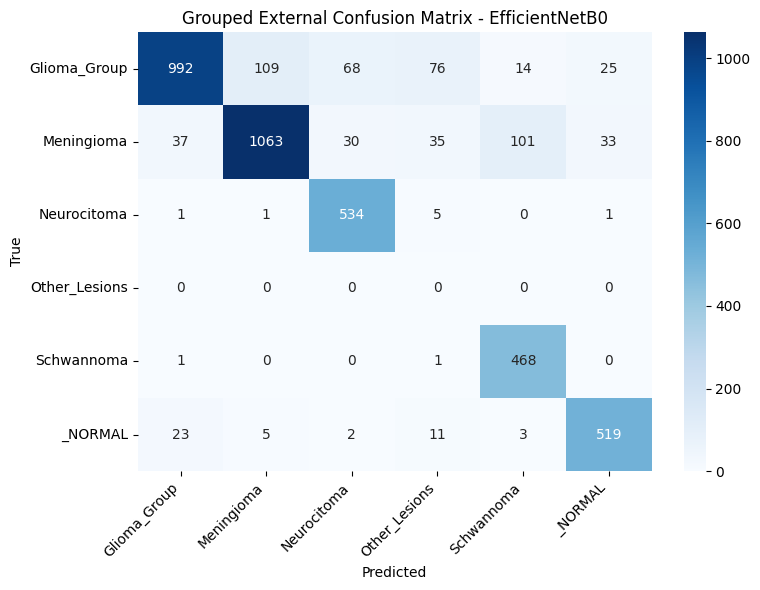


Grouped external evaluation for EfficientNetB5

Grouped classes used:
['Glioma_Group', 'Meningioma', 'Neurocitoma', 'Other_Lesions', 'Schwannoma', '_NORMAL']

Superclass to original-class indices:
Glioma_Group -> [0, 2, 3, 5, 10]
Meningioma -> [8]
Neurocitoma -> [9]
Other_Lesions -> [1, 4, 6, 7, 11, 13]
Schwannoma -> [12]
_NORMAL -> [14]
65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 340ms/step

Grouped External Accuracy: 0.8699

               precision    recall  f1-score   support

 Glioma_Group     0.9017    0.7718    0.8317      1284
   Meningioma     0.8551    0.8584    0.8567      1299
  Neurocitoma     0.8560    0.9871    0.9169       542
Other_Lesions     0.0000    0.0000    0.0000         0
   Schwannoma     0.8936    0.9830    0.9362       470
      _NORMAL     0.9923    0.9130    0.9510       563

     accuracy                         0.8699      4158
    macro avg     0.7498    0.7522    0.7487      4158
 weighted avg     0.8925    0.8699    0.8786      4158



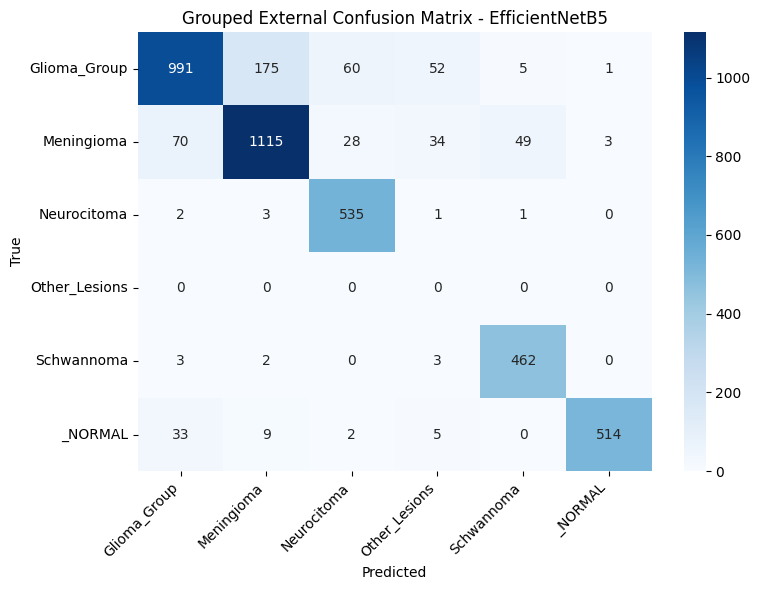


Grouped external evaluation for DenseNet121

Grouped classes used:
['Glioma_Group', 'Meningioma', 'Neurocitoma', 'Other_Lesions', 'Schwannoma', '_NORMAL']

Superclass to original-class indices:
Glioma_Group -> [0, 2, 3, 5, 10]
Meningioma -> [8]
Neurocitoma -> [9]
Other_Lesions -> [1, 4, 6, 7, 11, 13]
Schwannoma -> [12]
_NORMAL -> [14]
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 279ms/step

Grouped External Accuracy: 0.8908

               precision    recall  f1-score   support

 Glioma_Group     0.9268    0.8287    0.8750      1284
   Meningioma     0.8964    0.8661    0.8810      1299
  Neurocitoma     0.9114    0.9871    0.9477       542
Other_Lesions     0.0000    0.0000    0.0000         0
   Schwannoma     0.8561    0.9872    0.9170       470
      _NORMAL     0.9847    0.9165    0.9494       563

     accuracy                         0.8908      4158
    macro avg     0.7626    0.7643    0.7617      4158
 weighted avg     0.9152    0.8908    0.9012      4158



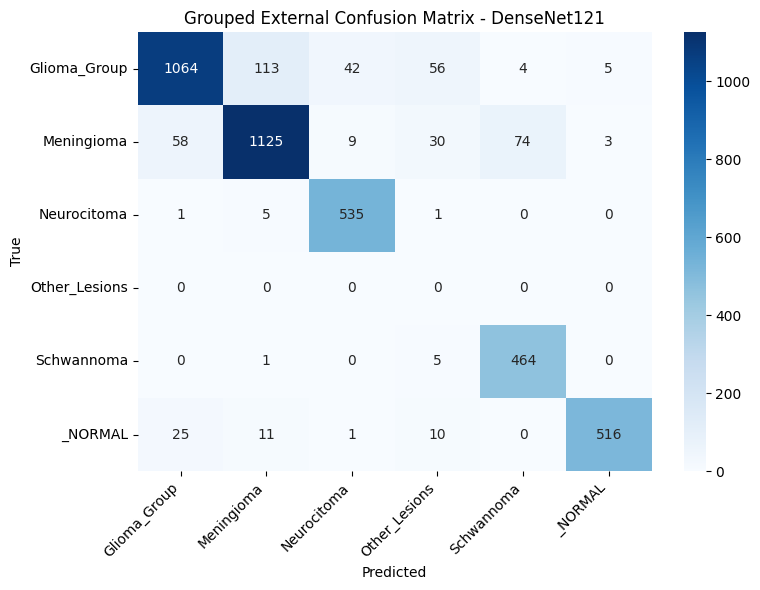


Final grouped external results:


,Model,Grouped External Accuracy,Grouped Classes,External Samples
0,EfficientNetB0_Simplified,0.818663,"Glioma_Group, Meningioma, Neurocitoma, Other_L...",4158
1,EfficientNetB0,0.860029,"Glioma_Group, Meningioma, Neurocitoma, Other_L...",4158
2,EfficientNetB5,0.869889,"Glioma_Group, Meningioma, Neurocitoma, Other_L...",4158
3,DenseNet121,0.890813,"Glioma_Group, Meningioma, Neurocitoma, Other_L...",4158


In [ ]:
external_grouped_df = prepare_grouped_external_df(path)

print("Grouped external label distribution:")
display(external_grouped_df["labels"].value_counts())

all_grouped_results = []

models_to_test = [
    ("EfficientNetB0_Simplified", efficientNet_model_b0R),
    ("EfficientNetB0", efficientNet_model_b0),
    ("EfficientNetB5", efficientNet_model_b5),
    ("DenseNet121", densenet121_model)
]

for model_name, model_obj in models_to_test:
    result_df = evaluate_model_grouped_external(
        model=model_obj,
        model_name=model_name,
        external_df=external_grouped_df,
        external_test_gen=external_test_gen,
        original_class_names=original_class_names
    )
    all_grouped_results.append(result_df)

final_grouped_results_df = pd.concat(all_grouped_results, ignore_index=True)

print("\nFinal grouped external results:")
display(final_grouped_results_df)

## models with just 5 clases

### b0 simplified


Evaluating EfficientNetB0_Simplified on external dataset

Matched classes used in evaluation:
Astrocitoma: class id 0
Meningioma: class id 8
Neurocitoma: class id 9
Schwannoma: class id 12
_NORMAL: class id 14
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 258ms/step

EfficientNetB0_Simplified - External Accuracy: 0.7694

Classification Report:

              precision    recall  f1-score   support

 Astrocitoma     0.8819    0.5350    0.6660      1284
  Meningioma     0.7052    0.7791    0.7403      1299
 Neurocitoma     0.7922    0.9428    0.8610       542
  Schwannoma     0.7467    0.9723    0.8447       470
     _NORMAL     0.7744    0.9449    0.8512       563

    accuracy                         0.7694      4158
   macro avg     0.7801    0.8348    0.7927      4158
weighted avg     0.7852    0.7694    0.7599      4158



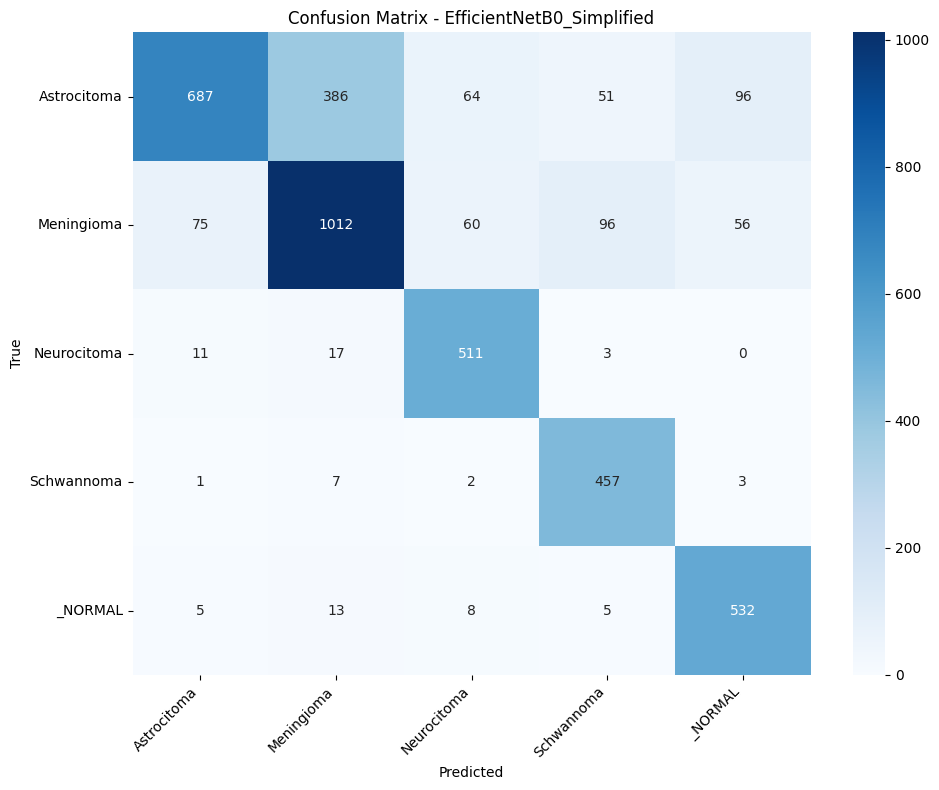

,Model,Matched Classes,Num Matched Classes,External Samples,Matched-Class External Accuracy
0,EfficientNetB0_Simplified,"Astrocitoma, Meningioma, Neurocitoma, Schwanno...",5,4158,0.76936


In [ ]:
model_to_test = efficientNet_model_b0R
model_name = "EfficientNetB0_Simplified"

external_result = evaluate_model_on_external_dataset_matched(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen,
    original_class_names=original_class_names,
    external_df=external_df
)

display(pd.DataFrame([external_result]))

### b0 baseline


Evaluating EfficientNetB0 on external dataset

Matched classes used in evaluation:
Astrocitoma: class id 0
Meningioma: class id 8
Neurocitoma: class id 9
Schwannoma: class id 12
_NORMAL: class id 14
65/65 ━━━━━━━━━━━━━━━━━━━━ 50s 535ms/step

EfficientNetB0 - External Accuracy: 0.8107

Classification Report:

              precision    recall  f1-score   support

 Astrocitoma     0.9414    0.5880    0.7239      1284
  Meningioma     0.8046    0.8337    0.8189      1299
 Neurocitoma     0.7767    0.9945    0.8722       542
  Schwannoma     0.7242    1.0000    0.8400       470
     _NORMAL     0.7856    0.9307    0.8520       563

    accuracy                         0.8107      4158
   macro avg     0.8065    0.8694    0.8214      4158
weighted avg     0.8315    0.8107    0.8034      4158



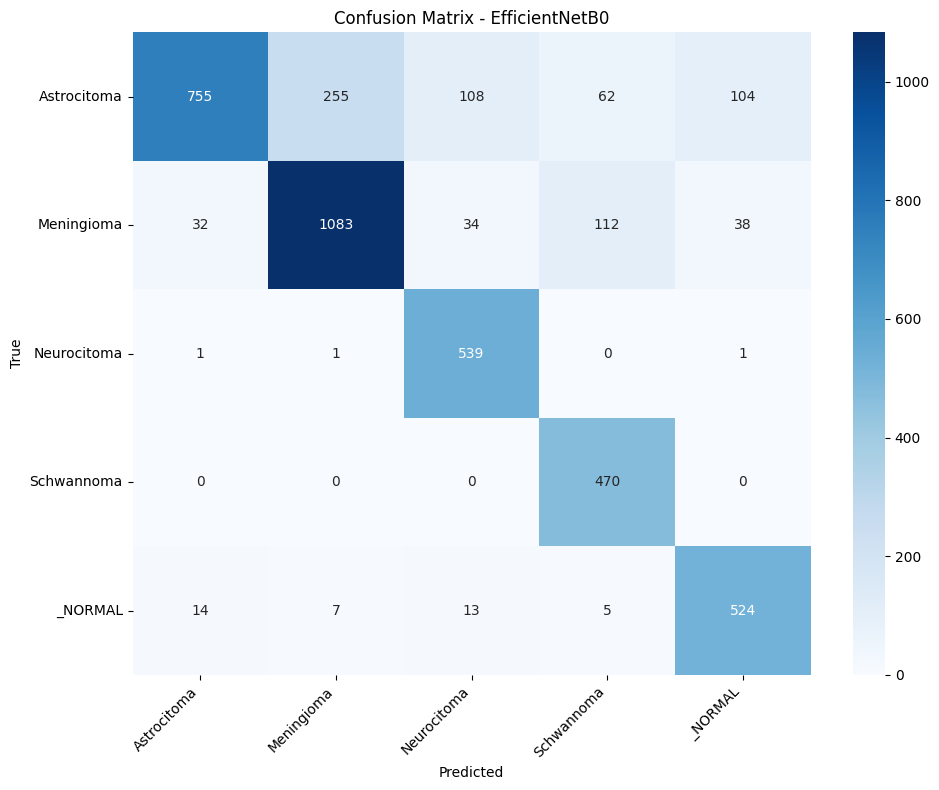

,Model,Matched Classes,Num Matched Classes,External Samples,Matched-Class External Accuracy
0,EfficientNetB0,"Astrocitoma, Meningioma, Neurocitoma, Schwanno...",5,4158,0.810726


In [ ]:
model_to_test = efficientNet_model_b0
model_name = "EfficientNetB0"

external_result = evaluate_model_on_external_dataset_matched(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen,
    original_class_names=original_class_names,
    external_df=external_df
)

display(pd.DataFrame([external_result]))

### b5


Evaluating EfficientNetB5 on external dataset

Matched classes used in evaluation:
Astrocitoma: class id 0
Meningioma: class id 8
Neurocitoma: class id 9
Schwannoma: class id 12
_NORMAL: class id 14
65/65 ━━━━━━━━━━━━━━━━━━━━ 79s 756ms/step

EfficientNetB5 - External Accuracy: 0.8023

Classification Report:

              precision    recall  f1-score   support

 Astrocitoma     0.9057    0.5164    0.6577      1284
  Meningioma     0.7261    0.8876    0.7988      1299
 Neurocitoma     0.8152    0.9926    0.8952       542
  Schwannoma     0.8643    0.9894    0.9226       470
     _NORMAL     0.8078    0.9183    0.8595       563

    accuracy                         0.8023      4158
   macro avg     0.8238    0.8608    0.8268      4158
weighted avg     0.8199    0.8023    0.7900      4158



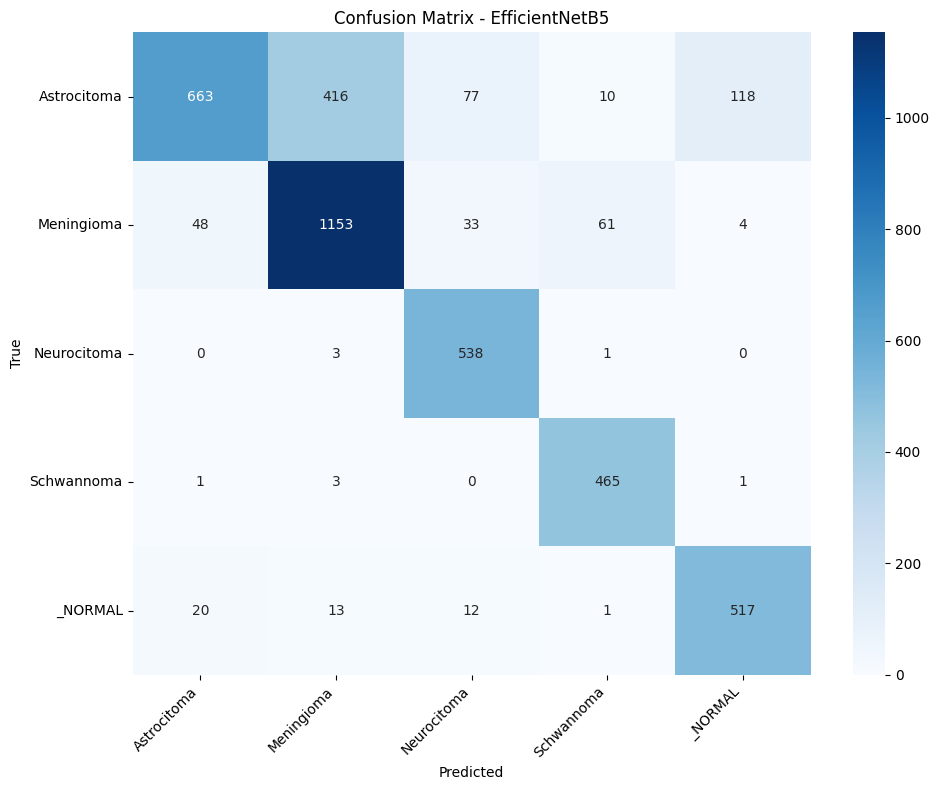

,Model,Matched Classes,Num Matched Classes,External Samples,Matched-Class External Accuracy
0,EfficientNetB5,"Astrocitoma, Meningioma, Neurocitoma, Schwanno...",5,4158,0.802309


In [ ]:
model_to_test = efficientNet_model_b5
model_name = "EfficientNetB5"

external_result = evaluate_model_on_external_dataset_matched(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen,
    original_class_names=original_class_names,
    external_df=external_df
)

display(pd.DataFrame([external_result]))

### densenet121


Evaluating DenseNet121 on external dataset

Matched classes used in evaluation:
Astrocitoma: class id 0
Meningioma: class id 8
Neurocitoma: class id 9
Schwannoma: class id 12
_NORMAL: class id 14
65/65 ━━━━━━━━━━━━━━━━━━━━ 63s 617ms/step

DenseNet121 - External Accuracy: 0.8598

Classification Report:

              precision    recall  f1-score   support

 Astrocitoma     0.9518    0.6768    0.7911      1284
  Meningioma     0.7798    0.9053    0.8379      1299
 Neurocitoma     0.8978    0.9889    0.9412       542
  Schwannoma     0.8086    0.9979    0.8933       470
     _NORMAL     0.9375    0.9325    0.9350       563

    accuracy                         0.8598      4158
   macro avg     0.8751    0.9003    0.8797      4158
weighted avg     0.8729    0.8598    0.8563      4158



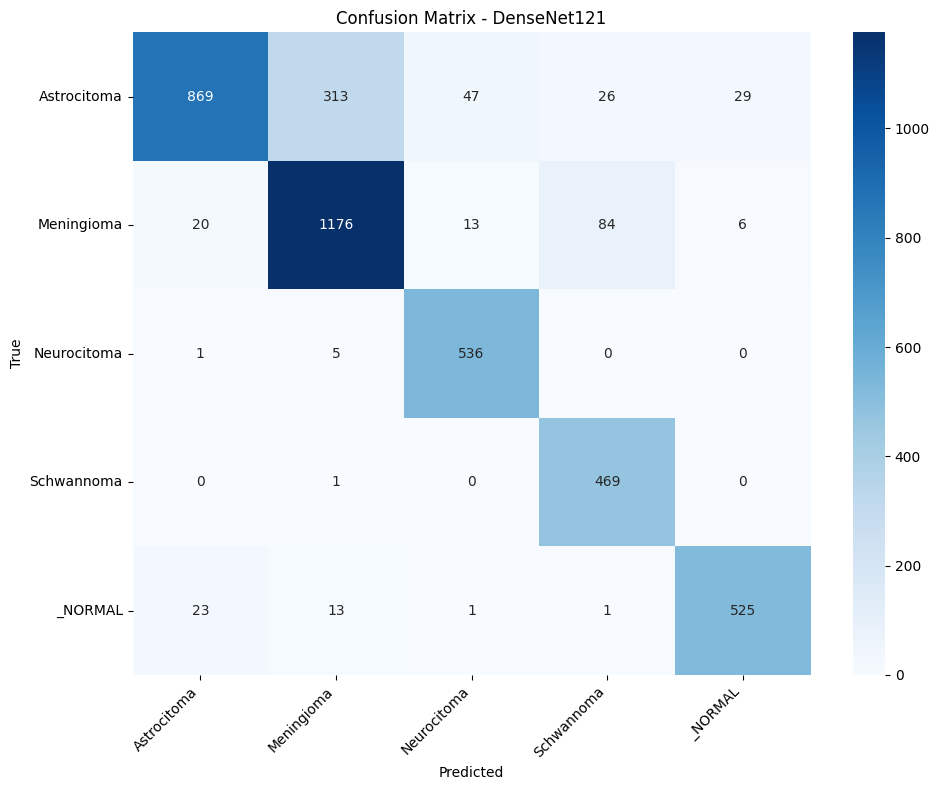

,Model,Matched Classes,Num Matched Classes,External Samples,Matched-Class External Accuracy
0,DenseNet121,"Astrocitoma, Meningioma, Neurocitoma, Schwanno...",5,4158,0.859788


In [ ]:
model_to_test = densenet121_model
model_name = "DenseNet121"

external_result = evaluate_model_on_external_dataset_matched(
    model=model_to_test,
    model_name=model_name,
    generator=external_test_gen,
    original_class_names=original_class_names,
    external_df=external_df
)

display(pd.DataFrame([external_result]))

# Final Remarks

This project developed and evaluated multiple deep learning models for multi-class brain tumor classification from MRI images, including EfficientNetB0, a simplified EfficientNetB0 variant, EfficientNetB5, and DenseNet121. The models were trained and tested on the main dataset using the same preprocessing pipeline and evaluation metrics in order to make the comparison fair and consistent.

The internal test results showed that the models were able to learn meaningful visual patterns from the training distribution and achieve strong performance on the original dataset. This indicates that transfer learning with modern CNN architectures is effective for brain tumor image classification when the training and testing data follow a similar distribution.

To strengthen the analysis, external testing was also performed on a different MRI dataset containing a larger number of tumor categories. Since the external dataset includes more detailed and specific tumor subclasses, its folder labels were mapped to the project’s original class names whenever a reliable match was possible. This allowed the trained models to be evaluated on unseen data without changing the original training labels.

Additional visual analysis was also included in the project. Sample images from the external dataset were displayed to better illustrate the nature of the new data, and misclassified examples were shown with their predicted and actual labels to help identify where the models failed. A separate section was added to visualize MRI samples from different directions or planes, since the external dataset contains scans acquired from multiple views rather than a single consistent orientation.

This external evaluation is important because it highlights one of the main limitations of the project: model generalization across datasets. The external dataset differs from the training dataset not only in class granularity, but also in MRI acquisition conditions, visual appearance, and scan direction. Some images come from different anatomical planes such as axial, sagittal, and coronal views, while the original dataset is more visually consistent. Because of this domain shift, the external accuracy is lower than the internal test accuracy. Therefore, the lower performance on the new dataset should not be interpreted only as model weakness, but also as evidence that the external samples come from a different and more challenging distribution.

Overall, the project shows that deep learning models can perform well for brain tumor MRI classification under controlled conditions, but also demonstrates that real-world robustness depends heavily on dataset diversity, label consistency, and imaging variability. Future improvements could include training with multi-source datasets, incorporating images from multiple MRI directions, applying stronger augmentation strategies, and using more advanced domain adaptation techniques to improve generalization on unseen medical data.

## References

1. **Dataset source**  
   Fernando2rad. *Brain Tumor MRI Images 44C*. Kaggle.  
   https://www.kaggle.com/datasets/fernando2rad/brain-tumor-mri-images-44c

2. **Transfer learning definition**  
   TensorFlow. *Transfer learning & fine-tuning*.  
   https://www.tensorflow.org/guide/keras/transfer_learning

3. **EfficientNet motivation**  
   Tan, M., & Le, Q. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. ICML / PMLR.  
   https://proceedings.mlr.press/v97/tan19a.html

4. **DenseNet motivation**  
   Huang, G., Liu, Z., van der Maaten, L., & Weinberger, K. Q. (2017). *Densely Connected Convolutional Networks*. CVPR.  
   https://openaccess.thecvf.com/content_cvpr_2017/html/Huang_Densely_Connected_Convolutional_CVPR_2017_paper.html

5. **External validation context in radiology AI**  
   Park, S. H., Han, K., et al. *External Validation of Deep Learning Algorithms for Radiologic Diagnosis: A Systematic Review*. RSNA / Radiology: Artificial Intelligence.  
   https://pubs.rsna.org/doi/abs/10.1148/ryai.210064